In [2]:
# Read in the anndata object
import anndata as ad
from pathlib import Path
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from scipy.stats import spearmanr, pearsonr
import scipy.sparse as sp
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.ticker import ScalarFormatter
import scanpy as sc
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from collections import defaultdict
import warnings
from adjustText import adjust_text

warnings.filterwarnings('ignore')

# Import LeafletFA differential splicing code
# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.differential_splicing as ds

In [3]:
# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *
from figure_plotting import * 

In [ ]:
# =============================================================================
# CONFIGURATION - EDIT THESE VALUES ONLY
# =============================================================================

# Main parameters to change
MODEL_TRAIN_DATE = "2025-07-03"
MODEL_ANALYSIS_DATE = "2025-07-04"
PARAM_ID = 2

# Base directories
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION"
RESULTS_BASE_DIR = "/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results"

# =============================================================================
# AUTO-GENERATED PATHS - DON'T EDIT BELOW THIS LINE
# =============================================================================

# Core result directories
PARAM_RESULTS_DIR = f"{RESULTS_BASE_DIR}/{MODEL_TRAIN_DATE}/{MODEL_ANALYSIS_DATE}/param_id_{PARAM_ID}"
DATA_DIR = f"{PARAM_RESULTS_DIR}/data"

# Model outputs
MODEL_OUTPUTS_DIR = f"{BASE_DIR}/Leaflet/leafletFAmodel/{MODEL_TRAIN_DATE}"
MODEL_PATH = f"{MODEL_OUTPUTS_DIR}/run_{PARAM_ID}/leafletfa_model.pkl.xz"

# Main data files
SPLICE_ADATA_PATH = f"{DATA_DIR}/splice_adata_PHI_psi_var_obs.h5ad"
PI_VALUES_PATH = f"{DATA_DIR}/PI_values.npy"
FACTOR_LABELS_PATH = f"{DATA_DIR}/factor_label_df.csv"
DIFF_SPL_PATH = f"{DATA_DIR}/differential_splicing_results.csv"
NMF_SINGLE_PATH = f"{DATA_DIR}/single_rbp_factor_correlations_rho.csv"

# Input data files (usually don't change)
ATSE_ANNDATA_PATH = (
    f"{BASE_DIR}/MODEL_INPUT/062025/"
    "HUMAN_SPLICING_FOUNDATION_Anndata_ATSE_counts_25909_junctions_30_waypoints_20250703_213217.h5ad"
)
GE_ANNDATA_scVI_PATH = f"{BASE_DIR}/scVI/ge_adata_with_both_scvi_models_2025-07-04.h5ad"
GE_ANNDATA_NMF_PATH = f"{BASE_DIR}/NMF/ge_adata_with_NMF_model_30_1024_2025-07-03.h5ad"

# Reference files
AGING_GENES_PATH = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/27857814"
RBP_FILE_PATH = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"

# Output directory for current analysis
OUTPUT_DIR = f"{PARAM_RESULTS_DIR}/analysis_outputs"

# =============================================================================
# LOAD DATA USING CONFIGURED PATHS
# =============================================================================

print(f"Loading data for param_id {PARAM_ID} from {MODEL_TRAIN_DATE}")
print(f"Data directory: {DATA_DIR}")

# Load main datasets
splice_adata = ad.read_h5ad(SPLICE_ADATA_PATH)
pi = np.load(PI_VALUES_PATH)
factor_labels = pd.read_csv(FACTOR_LABELS_PATH)
diff_spl = pd.read_csv(DIFF_SPL_PATH)
nmf_single = pd.read_csv(NMF_SINGLE_PATH)

print(f"Loaded splice_adata: {splice_adata.shape}")
print(f"Loaded PI values: {pi.shape}")
print(f"Loaded factor_labels: {factor_labels.shape}")
print(f"Loaded diff_spl: {diff_spl.shape}")
print(f"Loaded nmf_single: {nmf_single.shape}")

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

ATSE_FILE_PATH = (
    f"{BASE_DIR}/ATSE_mapper/ATSE_files/stella_gtf/TMS_atse_file_unanno_also_2025-07-01_03-02-03.txt.gz"
)

# Load splicing data
ge_adata = ad.read_h5ad(GE_ANNDATA_scVI_PATH)
ge_adata_nmf = ad.read_h5ad(GE_ANNDATA_NMF_PATH)
# If ge_adata.obs doesn't have cell_id make it from cell_id_clean
if "cell_id" not in ge_adata.obs.columns:
    ge_adata.obs["cell_id"] = ge_adata.obs["cell_id_clean"]
    ge_adata_nmf.obs["cell_id"] = ge_adata_nmf.obs["cell_id_clean"]

assert np.all(ge_adata.obs["cell_id"].values == splice_adata.obs["cell_id"].values), "Cell IDs in ge_adata and splice_adata do not match or are not in the same order."

# Load aging gene lists
aging_genes_mouse, aging_genes_human = load_aging_genes(AGING_GENES_PATH)
    
# Load RBP genes
rbps = load_rbp_genes(RBP_FILE_PATH)
    
# If ge_adata.var["gene_name"] is not in ge_adata.var_names, then add it
if "gene_name" not in ge_adata.var.columns:
    ge_adata.var["gene_name"] = ge_adata.var_names

# if "mouse.id" is in splice_adata.obs rename it to donor_id 
if "mouse.id" in splice_adata.obs.columns:
    print(f"Renaming mouse.id to donor_id in splice_adata.obs")
    splice_adata.obs.rename(columns={"mouse.id": "donor_id"}, inplace=True)
    # Update gene annotations
    ge_adata.var["RBP_gene"] = ge_adata.var["gene_name"].isin(rbps["mouse_gene_name"])
    ge_adata.var["Aging_gene"] = ge_adata.var["gene_name"].isin(aging_genes_mouse)
    rbps = rbps["mouse_gene_name"]
    print(ge_adata.var["RBP_gene"])
    print(ge_adata.var["Aging_gene"])

else:
    splice_adata.var = add_gene_symbols_to_var(splice_adata.var)
    splice_adata.var["RBP_gene"] = splice_adata.var["gene_name"].isin(rbps["gene_name"]) # when running with Human data... 
    splice_adata.var["Aging_gene"] = splice_adata.var["gene_name"].isin(aging_genes_human)
        
    ge_adata.var["RBP_gene"] = ge_adata.var["gene_name"].isin(rbps["gene_name"])
    ge_adata.var["Aging_gene"] = ge_adata.var["gene_name"].isin(aging_genes_human)
    aging_genes = aging_genes_human
    rbps = rbps["gene_name"]

assert np.all(ge_adata.obs_names == ge_adata_nmf.obs_names), "Cell IDs in ge_adata and ge_adata_nmf do not match or are not in the same order."
assert np.all(ge_adata.var_names == ge_adata_nmf.var_names), "Gene names in ge_adata and ge_adata_nmf do not match or are not in the same order."
ge_adata.obsm["X_nmf_standard_mb"] = ge_adata_nmf.obsm["X_nmf_standard_mb"]
ge_adata.varm["nmf_standard_mb_components"] = ge_adata_nmf.varm["nmf_standard_mb_components"]

# Check if predicted_log_norm_tms not in ge_adata.layers then ge_layer_name="log_norm"
ge_layer_name = "log_norm"

# Load ATSE file
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
atse_df = atse_df[["junction_id", "perfect_match_5_prime", "perfect_match_3_prime"]]
atse_df["junction_annotation"] = "Novel_SS" 
# If perfect_match_5_prime is nonempty then set junction_annotation to "5_prime_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna(), "junction_annotation"] = "5_prime_annotated"
# If perfect_match_3_prime is nonempty then set junction_annotation to "3_prime_annotated"
atse_df.loc[atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "3_prime_annotated"
# If perfect_match_5_prime and perfect_match_3_prime are both nonempty then set junction_annotation to "Both_SS_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna() & atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "Both_SS_annotated"

# Load the model
leaflet_model = load_model(MODEL_PATH)

# Read in full splice adata 
splice_adata_full=ad.read_h5ad(ATSE_ANNDATA_PATH)

Loading data for param_id 2 from 2025-07-03
Data directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-03/2025-07-04/param_id_2/data
Loaded splice_adata: (80780, 25909)
Loaded PI values: (24,)
Loaded factor_labels: (24, 9)
Loaded diff_spl: (36934, 49)
Loaded nmf_single: (46, 25)
Output directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-03/2025-07-04/param_id_2/analysis_outputs
Loaded 330 aging-related genes (mouse)
Loaded 330 aging-related genes (human)
Loaded 356 RNA binding proteins


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


Querying MyGeneInfo to map Ensembl gene IDs to gene symbols...
Mapped 25898 gene IDs to gene symbols.
Loading model to device: cpu


### Add module labels to cell types 

In [5]:
# Count cells per cell type
cell_type_counts = splice_adata.obs["broad_cell_type"].value_counts()

# Keep only cell types with at least 50 cells
valid_cell_types = cell_type_counts[cell_type_counts >= 50].index

# Subset the AnnData
filtered_splice_adata = splice_adata[splice_adata.obs["broad_cell_type"].isin(valid_cell_types)].copy()
filtered_splice_adata.obs_names = filtered_splice_adata.obs["cell_id_clean"]

print(filtered_splice_adata.shape)
print(filtered_splice_adata.obs["broad_cell_type"].value_counts())

# Subset ge_adata to match cells in filtered_splice_adata, preserving order
filtered_ge_adata = ge_adata[filtered_splice_adata.obs_names].copy()
assert all(filtered_splice_adata.obs_names == filtered_ge_adata.obs_names)

(80740, 25909)
broad_cell_type
Excitatory_Neuron            30669
Inhibitory_Neuron            10861
CNS_Glia                      3872
CD4_T_cell                    3075
Granulocyte                   2580
Monocyte                      2504
General_Fibroblast            2435
B_cell                        2391
Macrophage                    2298
CD8_T_cell                    2248
GI_Epithelial                 2160
Specialized_Endothelial       1841
NK_ILC                        1715
Other                         1397
Mesenchymal_Stem              1214
Other_T_cell                   999
Plasma_cell                    994
Capillary_Endothelial          806
Microglia                      802
Skeletal_Muscle                654
Pericyte                       595
Smooth_Muscle                  571
Alveolar_cell                  439
Urogenital_Epithelial          411
Other_Epithelial               402
Venous_Endothelial             368
Other_Neuron                   318
Organ_Specific_Fibroblas

In [6]:
# Create biologically meaningful cell type modules
def assign_cell_type_modules(cell_type):
    """
    Assign cell types to biologically meaningful modules based on:
    1. Developmental lineage
    2. Functional similarity  
    3. Metabolic/physiological roles
    """
    
    # Neural/CNS Module - shared neural development and function
    neural_cns = [
        'Excitatory_Neuron', 'Inhibitory_Neuron', 'Other_Neuron',
        'CNS_Glia', 'Microglia'
    ]
    
    # Immune Module - hematopoietic lineage, immune function
    immune = [
        'CD4_T_cell', 'CD8_T_cell', 'Other_T_cell', 'Regulatory_T_cell',
        'B_cell', 'Plasma_cell', 'NK_ILC',
        'Monocyte', 'Macrophage', 'Dendritic_cell',
        'Granulocyte', 'Immune_Other', 'Myeloid_Other',
        'Hematopoietic_Progenitor', 'Hematopoietic_Mature'
    ]
    
    # Vascular/Endothelial Module - shared vascular development and function
    vascular = [
        'Specialized_Endothelial', 'Capillary_Endothelial', 
        'Venous_Endothelial', 'Arterial_Endothelial', 
        'Lymphatic_Endothelial', 'Endothelial'
    ]
    
    # Mesenchymal/Stromal Module - mesenchymal origin, structural support
    mesenchymal = [
        'General_Fibroblast', 'Organ_Specific_Fibroblast',
        'Mesenchymal_Stem', 'Pericyte'
    ]
    
    # Muscle Module - contractile function, high energy demands
    muscle = [
        'Skeletal_Muscle', 'Smooth_Muscle', 'Muscle_Other'
    ]
    
    # Epithelial Module - barrier function, secretion
    epithelial = [
        'GI_Epithelial', 'Urogenital_Epithelial', 'Other_Epithelial',
        'Respiratory_Epithelial', 'Mammary_Epithelial'
    ]
    
    # Specialized Secretory - specialized metabolic/secretory functions
    specialized_secretory = [
        'Alveolar_cell', 'Secretory_Gland'
    ]
    
    # Peripheral Neural - PNS development and function
    peripheral_neural = [
        'PNS_Glia'
    ]
    
    # Stem/Progenitor - multipotent, developmental
    stem_progenitor = [
        'Stem_Progenitor_Other'
    ]
    
    # Other/Undefined
    other = [
        'Other'
    ]
    
    # Assign modules
    if cell_type in neural_cns:
        return 'Neural_CNS'
    elif cell_type in immune:
        return 'Immune_Hematopoietic'
    elif cell_type in vascular:
        return 'Vascular_Endothelial'
    elif cell_type in mesenchymal:
        return 'Mesenchymal_Stromal'
    elif cell_type in muscle:
        return 'Muscle_Contractile'
    elif cell_type in epithelial:
        return 'Epithelial_Barrier'
    elif cell_type in specialized_secretory:
        return 'Specialized_Secretory'
    elif cell_type in peripheral_neural:
        return 'Peripheral_Neural'
    elif cell_type in stem_progenitor:
        return 'Stem_Progenitor'
    elif cell_type in other:
        return 'Other_Undefined'
    else:
        return 'Unclassified'

# Create a more detailed functional classification
def assign_functional_categories(cell_type):
    """
    Alternative classification based on primary function
    """
    
    # Information Processing
    information_processing = [
        'Excitatory_Neuron', 'Inhibitory_Neuron', 'Other_Neuron',
        'CNS_Glia', 'PNS_Glia'
    ]
    
    # Defense & Immunity
    defense_immunity = [
        'CD4_T_cell', 'CD8_T_cell', 'Other_T_cell', 'Regulatory_T_cell',
        'B_cell', 'Plasma_cell', 'NK_ILC',
        'Monocyte', 'Macrophage', 'Dendritic_cell', 'Microglia',
        'Granulocyte', 'Immune_Other', 'Myeloid_Other'
    ]
    
    # Transport & Circulation
    transport_circulation = [
        'Specialized_Endothelial', 'Capillary_Endothelial', 
        'Venous_Endothelial', 'Arterial_Endothelial', 
        'Lymphatic_Endothelial', 'Endothelial'
    ]
    
    # Structure & Support
    structure_support = [
        'General_Fibroblast', 'Organ_Specific_Fibroblast',
        'Mesenchymal_Stem', 'Pericyte'
    ]
    
    # Movement & Contraction
    movement_contraction = [
        'Skeletal_Muscle', 'Smooth_Muscle', 'Muscle_Other'
    ]
    
    # Barrier & Protection
    barrier_protection = [
        'GI_Epithelial', 'Urogenital_Epithelial', 'Other_Epithelial',
        'Respiratory_Epithelial', 'Mammary_Epithelial'
    ]
    
    # Gas Exchange & Secretion
    exchange_secretion = [
        'Alveolar_cell', 'Secretory_Gland'
    ]
    
    # Regeneration & Development
    regeneration_development = [
        'Hematopoietic_Progenitor', 'Hematopoietic_Mature',
        'Stem_Progenitor_Other'
    ]
    
    # Assign functional categories
    if cell_type in information_processing:
        return 'Information_Processing'
    elif cell_type in defense_immunity:
        return 'Defense_Immunity'
    elif cell_type in transport_circulation:
        return 'Transport_Circulation'
    elif cell_type in structure_support:
        return 'Structure_Support'
    elif cell_type in movement_contraction:
        return 'Movement_Contraction'
    elif cell_type in barrier_protection:
        return 'Barrier_Protection'
    elif cell_type in exchange_secretion:
        return 'Exchange_Secretion'
    elif cell_type in regeneration_development:
        return 'Regeneration_Development'
    else:
        return 'Other_Function'

# Tissue/System based classification
def assign_tissue_system(cell_type):
    """
    Classification based on tissue/organ system
    """
    
    # Central Nervous System
    cns = ['Excitatory_Neuron', 'Inhibitory_Neuron', 'Other_Neuron', 'CNS_Glia', 'Microglia']
    
    # Peripheral Nervous System  
    pns = ['PNS_Glia']
    
    # Immune System
    immune_system = [
        'CD4_T_cell', 'CD8_T_cell', 'Other_T_cell', 'Regulatory_T_cell',
        'B_cell', 'Plasma_cell', 'NK_ILC', 'Monocyte', 'Macrophage', 
        'Dendritic_cell', 'Granulocyte', 'Immune_Other', 'Myeloid_Other',
        'Hematopoietic_Progenitor', 'Hematopoietic_Mature'
    ]
    
    # Cardiovascular System
    cardiovascular = [
        'Specialized_Endothelial', 'Capillary_Endothelial', 
        'Venous_Endothelial', 'Arterial_Endothelial', 'Endothelial'
    ]
    
    # Lymphatic System
    lymphatic = ['Lymphatic_Endothelial']
    
    # Musculoskeletal System
    musculoskeletal = ['Skeletal_Muscle', 'Muscle_Other']
    
    # Smooth Muscle (various organs)
    smooth_muscle_system = ['Smooth_Muscle']
    
    # Digestive System
    digestive = ['GI_Epithelial']
    
    # Respiratory System
    respiratory = ['Alveolar_cell', 'Respiratory_Epithelial']
    
    # Urogenital System
    urogenital = ['Urogenital_Epithelial']
    
    # Mammary System
    mammary = ['Mammary_Epithelial']
    
    # Connective Tissue (pan-system)
    connective = ['General_Fibroblast', 'Organ_Specific_Fibroblast', 'Mesenchymal_Stem', 'Pericyte']
    
    # Assign systems
    if cell_type in cns:
        return 'Central_Nervous_System'
    elif cell_type in pns:
        return 'Peripheral_Nervous_System'
    elif cell_type in immune_system:
        return 'Immune_System'
    elif cell_type in cardiovascular:
        return 'Cardiovascular_System'
    elif cell_type in lymphatic:
        return 'Lymphatic_System'
    elif cell_type in musculoskeletal:
        return 'Musculoskeletal_System'
    elif cell_type in smooth_muscle_system:
        return 'Smooth_Muscle_System'
    elif cell_type in digestive:
        return 'Digestive_System'
    elif cell_type in respiratory:
        return 'Respiratory_System'
    elif cell_type in urogenital:
        return 'Urogenital_System'
    elif cell_type in mammary:
        return 'Mammary_System'
    elif cell_type in connective:
        return 'Connective_Tissue'
    else:
        return 'Other_System'

# Additional cell type classifications
def assign_lifespan_category(cell_type):
    """
    Classify cell types by typical lifespan/turnover rate
    Based on known biology of cell renewal and longevity
    """
    
    # Short-lived cells (days to weeks) - high turnover
    short_lived = [
        'Granulocyte',  # Neutrophils ~1-2 days
        'GI_Epithelial',  # GI epithelium ~3-5 days
        'Respiratory_Epithelial',  # Lung epithelium ~1-3 weeks
        'Hematopoietic_Progenitor',  # Rapidly dividing
        'Other_Epithelial',  # Most epithelial cells turn over rapidly
        'Alveolar_cell'  # Pneumocytes can turn over rapidly
    ]
    
    # Medium-lived cells (weeks to months)
    medium_lived = [
        'CD4_T_cell', 'CD8_T_cell', 'Other_T_cell',  # T cells vary, but many are medium-term
        'B_cell',  # Naive B cells ~weeks to months
        'NK_ILC',  # Natural killer cells ~weeks
        'Monocyte',  # ~1-3 days in blood, longer in tissues
        'Macrophage',  # Tissue macrophages ~months
        'Dendritic_cell',  # ~weeks to months
        'Immune_Other', 'Myeloid_Other',
        'Urogenital_Epithelial',  # Varies by location
        'Mammary_Epithelial',  # Cyclical renewal
        'Secretory_Gland'  # Varies by gland type
    ]
    
    # Long-lived cells (months to years to lifetime)
    long_lived = [
        'Excitatory_Neuron', 'Inhibitory_Neuron', 'Other_Neuron',  # Neurons last lifetime
        'CNS_Glia',  # Oligodendrocytes and astrocytes are long-lived
        'PNS_Glia',  # Schwann cells are long-lived
        'Plasma_cell',  # Long-lived plasma cells can persist for years
        'Regulatory_T_cell',  # Memory T cells can be very long-lived
        'Skeletal_Muscle',  # Muscle fibers last years-lifetime
        'Smooth_Muscle',  # Long-lived
        'Muscle_Other',
        'General_Fibroblast', 'Organ_Specific_Fibroblast',  # Fibroblasts are long-lived
        'Specialized_Endothelial', 'Capillary_Endothelial',  # Endothelial cells are long-lived
        'Venous_Endothelial', 'Arterial_Endothelial', 'Lymphatic_Endothelial', 'Endothelial',
        'Pericyte',  # Long-lived
        'Hematopoietic_Mature'  # Mature long-lived blood cells
    ]
    
    # Variable/Context-dependent lifespan
    variable_lived = [
        'Microglia',  # Can be long-lived but also replaced
        'Mesenchymal_Stem',  # Stem cells - variable activity
        'Stem_Progenitor_Other',  # Depends on tissue context
        'Other',  # Unknown
        'Immune_Other'  # Could be either
    ]
    
    # Assign lifespan categories
    if cell_type in short_lived:
        return 'Short_Lived'  # Days to weeks
    elif cell_type in medium_lived:
        return 'Medium_Lived'  # Weeks to months
    elif cell_type in long_lived:
        return 'Long_Lived'  # Months to lifetime
    elif cell_type in variable_lived:
        return 'Variable_Lived'  # Context-dependent
    else:
        return 'Unknown_Lifespan'

def assign_simple_category(cell_type):
    """
    Simple 6-category classification for broad analysis
    """
    
    # Immune cells - all hematopoietic immune cells
    immune = [
        'CD4_T_cell', 'CD8_T_cell', 'Other_T_cell', 'Regulatory_T_cell',
        'B_cell', 'Plasma_cell', 'NK_ILC',
        'Monocyte', 'Macrophage', 'Dendritic_cell', 'Microglia',
        'Granulocyte', 'Immune_Other', 'Myeloid_Other'
    ]
    
    # Stem cells and progenitors - multipotent cells
    stem_progenitor = [
        'Hematopoietic_Progenitor', 'Hematopoietic_Mature',
        'Mesenchymal_Stem', 'Stem_Progenitor_Other'
    ]
    
    # Stromal cells - structural support, connective tissue
    stromal = [
        'General_Fibroblast', 'Organ_Specific_Fibroblast',
        'Pericyte'
    ]
    
    # Endothelial cells - all vascular lining cells
    endothelial = [
        'Specialized_Endothelial', 'Capillary_Endothelial',
        'Venous_Endothelial', 'Arterial_Endothelial',
        'Lymphatic_Endothelial', 'Endothelial'
    ]
    
    # Epithelial cells - barrier-forming cells
    epithelial = [
        'GI_Epithelial', 'Urogenital_Epithelial', 'Other_Epithelial',
        'Respiratory_Epithelial', 'Mammary_Epithelial',
        'Alveolar_cell', 'Secretory_Gland'
    ]
    
    # Parenchymal cells - organ-specific functional cells
    parenchymal = [
        'Excitatory_Neuron', 'Inhibitory_Neuron', 'Other_Neuron',  # Brain parenchyma
        'CNS_Glia', 'PNS_Glia',  # Neural support
        'Skeletal_Muscle', 'Smooth_Muscle', 'Muscle_Other'  # Muscle parenchyma
    ]
    
    # Assign simple categories
    if cell_type in immune:
        return 'Immune'
    elif cell_type in stem_progenitor:
        return 'Stem_Progenitor'
    elif cell_type in stromal:
        return 'Stromal'
    elif cell_type in endothelial:
        return 'Endothelial'
    elif cell_type in epithelial:
        return 'Epithelial'
    elif cell_type in parenchymal:
        return 'Parenchymal'
    else:
        return 'Other'

# Add senescence-prone classification first
def assign_senescence_proneness(cell_type):
    """
    Classify cell types by their tendency to undergo senescence
    Based on literature on cellular senescence patterns
    """
    
    # High senescence-prone cells - actively divide, accumulate damage over time
    high_senescence = [
        'General_Fibroblast', 'Organ_Specific_Fibroblast',  # Classic senescence model
        'Mesenchymal_Stem',  # MSCs are highly senescence-prone
        'Specialized_Endothelial', 'Capillary_Endothelial',  # Endothelial senescence is well-documented
        'Venous_Endothelial', 'Arterial_Endothelial', 'Endothelial',
        'Smooth_Muscle',  # Vascular smooth muscle undergoes senescence
        'GI_Epithelial',  # High turnover epithelium accumulates senescent cells
        'Respiratory_Epithelial', 'Other_Epithelial',
        'Secretory_Gland'  # Secretory cells can undergo senescence
    ]
    
    # Moderate senescence-prone cells - some turnover, moderate senescence
    moderate_senescence = [
        'CNS_Glia',  # Astrocytes and oligodendrocytes can senesce
        'Pericyte',  # Vascular pericytes undergo senescence
        'Skeletal_Muscle',  # Satellite cells and muscle fibers can senesce
        'Lymphatic_Endothelial',
        'Macrophage',  # Tissue macrophages can undergo senescence
        'Urogenital_Epithelial', 'Mammary_Epithelial',
        'Alveolar_cell'  # Lung epithelium can senesce
    ]
    
    # Low senescence-prone cells - post-mitotic or rapid turnover
    low_senescence = [
        'Excitatory_Neuron', 'Inhibitory_Neuron', 'Other_Neuron',  # Post-mitotic, rarely senesce
        'PNS_Glia',  # Less prone to senescence than CNS glia
        'Granulocyte',  # Too short-lived to accumulate senescence
        'CD4_T_cell', 'CD8_T_cell', 'Other_T_cell',  # Active immune cells, high turnover
        'B_cell', 'NK_ILC',  # High turnover immune cells
        'Monocyte', 'Dendritic_cell',  # Rapid turnover
        'Hematopoietic_Progenitor', 'Hematopoietic_Mature'  # Hematopoietic cells turn over rapidly
    ]
    
    # Variable/context-dependent senescence
    variable_senescence = [
        'Microglia',  # Can undergo senescence but also self-renew
        'Plasma_cell',  # Long-lived plasma cells may senesce
        'Regulatory_T_cell',  # Memory T cells may accumulate senescence
        'Muscle_Other',  # Depends on specific muscle type
        'Stem_Progenitor_Other',  # Depends on specific stem cell type
        'Immune_Other', 'Myeloid_Other',  # Context-dependent
        'Other'  # Unknown
    ]
    
    # Assign senescence categories
    if cell_type in high_senescence:
        return 'High_Senescence_Prone'
    elif cell_type in moderate_senescence:
        return 'Moderate_Senescence_Prone'
    elif cell_type in low_senescence:
        return 'Low_Senescence_Prone'
    elif cell_type in variable_senescence:
        return 'Variable_Senescence'
    else:
        return 'Unknown_Senescence'

In [7]:
# Apply the module assignment
filtered_splice_adata.obs['cell_type_module'] = filtered_splice_adata.obs['broad_cell_type'].apply(assign_cell_type_modules)

# Check the distribution
print("Cell Type Module Distribution:")
module_counts = filtered_splice_adata.obs['cell_type_module'].value_counts()
print(module_counts)

# Show module composition
print("\nModule Composition:")
for module in module_counts.index:
    print(f"\n{module}:")
    cell_types_in_module = filtered_splice_adata.obs[filtered_splice_adata.obs['cell_type_module'] == module]['broad_cell_type'].value_counts()
    for cell_type, count in cell_types_in_module.items():
        print(f"  {cell_type}: {count:,}")

# Apply functional classification
filtered_splice_adata.obs['functional_category'] = filtered_splice_adata.obs['broad_cell_type'].apply(assign_functional_categories)

print("\n" + "="*60)
print("Functional Category Distribution:")
functional_counts = filtered_splice_adata.obs['functional_category'].value_counts()
print(functional_counts)

# Apply tissue/system classification
filtered_splice_adata.obs['tissue_system'] = filtered_splice_adata.obs['broad_cell_type'].apply(assign_tissue_system)

print("\n" + "="*60)
print("Tissue/System Distribution:")
system_counts = filtered_splice_adata.obs['tissue_system'].value_counts()
print(system_counts)

# Save the updated data
print(f"\nAdded three new columns to filtered_splice_adata.obs:")
print(f"- 'cell_type_module': Developmental/lineage-based modules")
print(f"- 'functional_category': Function-based categories")
print(f"- 'tissue_system': Tissue/organ system classification")

Cell Type Module Distribution:
cell_type_module
Neural_CNS               46522
Immune_Hematopoietic     19673
Mesenchymal_Stromal       4538
Vascular_Endothelial      3363
Epithelial_Barrier        3217
Other_Undefined           1397
Muscle_Contractile        1285
Specialized_Secretory      606
Stem_Progenitor             72
Peripheral_Neural           67
Name: count, dtype: int64

Module Composition:

Neural_CNS:
  Excitatory_Neuron: 30,669
  Inhibitory_Neuron: 10,861
  CNS_Glia: 3,872
  Microglia: 802
  Other_Neuron: 318
  Pericyte: 0
  NK_ILC: 0
  Organ_Specific_Fibroblast: 0
  Other: 0
  Other_Epithelial: 0
  Other_T_cell: 0
  PNS_Glia: 0
  Regulatory_T_cell: 0
  Plasma_cell: 0
  Muscle_Other: 0
  Respiratory_Epithelial: 0
  Secretory_Gland: 0
  Skeletal_Muscle: 0
  Smooth_Muscle: 0
  Specialized_Endothelial: 0
  Stem_Progenitor_Other: 0
  Urogenital_Epithelial: 0
  Myeloid_Other: 0
  Alveolar_cell: 0
  Monocyte: 0
  General_Fibroblast: 0
  B_cell: 0
  CD4_T_cell: 0
  CD8_T_cell: 0

Lifespan Category Distribution:
lifespan_category
Long_Lived        54960
Medium_Lived      16240
Short_Lived        6055
Variable_Lived     3485
Name: count, dtype: int64

Simple Category Distribution:
simple_category
Parenchymal        47072
Immune             20061
Epithelial          3823
Endothelial         3363
Stromal             3324
Stem_Progenitor     1700
Other               1397
Name: count, dtype: int64


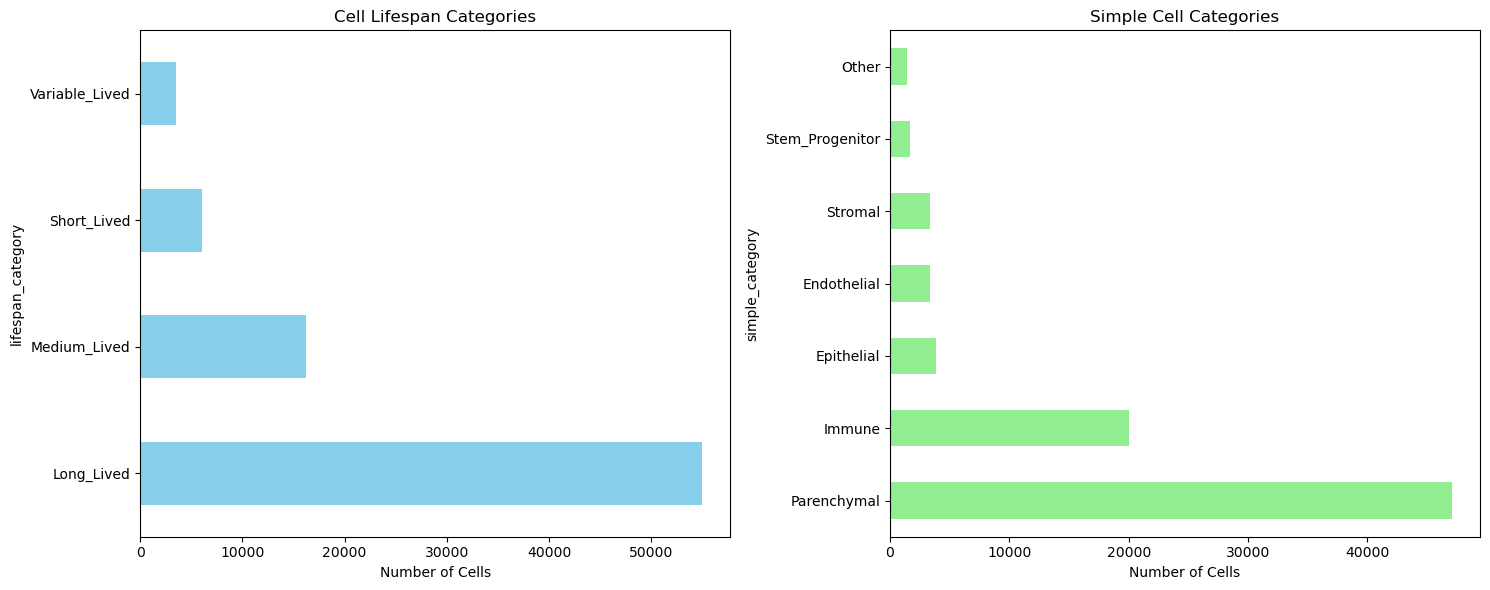

In [8]:
# Apply the new classifications
filtered_splice_adata.obs['lifespan_category'] = filtered_splice_adata.obs['broad_cell_type'].apply(assign_lifespan_category)
filtered_splice_adata.obs['simple_category'] = filtered_splice_adata.obs['broad_cell_type'].apply(assign_simple_category)

# Check distributions
print("Lifespan Category Distribution:")
lifespan_counts = filtered_splice_adata.obs['lifespan_category'].value_counts()
print(lifespan_counts)

print("\n" + "="*50)
print("Simple Category Distribution:")
simple_counts = filtered_splice_adata.obs['simple_category'].value_counts()
print(simple_counts)

# Create visualization
def plot_new_classifications():
    """Plot the new classification distributions"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Lifespan distribution
    lifespan_counts.plot(kind='barh', ax=axes[0], color='skyblue')
    axes[0].set_title('Cell Lifespan Categories')
    axes[0].set_xlabel('Number of Cells')
    
    # Simple category distribution
    simple_counts.plot(kind='barh', ax=axes[1], color='lightgreen')
    axes[1].set_title('Simple Cell Categories')
    axes[1].set_xlabel('Number of Cells')
    
    plt.tight_layout()
    plt.show()
    
# Run visualization
plot_new_classifications()

- High_Senescence_Prone: Fibroblasts, endothelial cells, smooth muscle, epithelial cells
- Moderate_Senescence_Prone: CNS glia, pericytes, skeletal muscle, some epithelial
- Low_Senescence_Prone: Neurons (post-mitotic), immune cells (high turnover)
- Variable_Senescence: Context-dependent (microglia, memory cells)

In [9]:
# Add senescence classification
filtered_splice_adata.obs['senescence_proneness'] = filtered_splice_adata.obs['broad_cell_type'].apply(assign_senescence_proneness)

# Check distribution
print("Senescence Proneness Distribution:")
senescence_counts = filtered_splice_adata.obs['senescence_proneness'].value_counts()
print(senescence_counts)

Senescence Proneness Distribution:
senescence_proneness
Low_Senescence_Prone         58012
High_Senescence_Prone        10671
Moderate_Senescence_Prone     8448
Variable_Senescence           3609
Name: count, dtype: int64


Lifespan Category Breakdown by Cell Type:
lifespan_category          Long_Lived  Medium_Lived  Short_Lived  \
broad_cell_type                                                    
Excitatory_Neuron               30669             0            0   
Inhibitory_Neuron               10861             0            0   
CNS_Glia                         3872             0            0   
CD4_T_cell                          0          3075            0   
Granulocyte                         0             0         2580   
Monocyte                            0          2504            0   
General_Fibroblast               2435             0            0   
B_cell                              0          2391            0   
Macrophage                          0          2298            0   
CD8_T_cell                          0          2248            0   
GI_Epithelial                       0             0         2160   
Specialized_Endothelial          1841             0            0   
NK_ILC

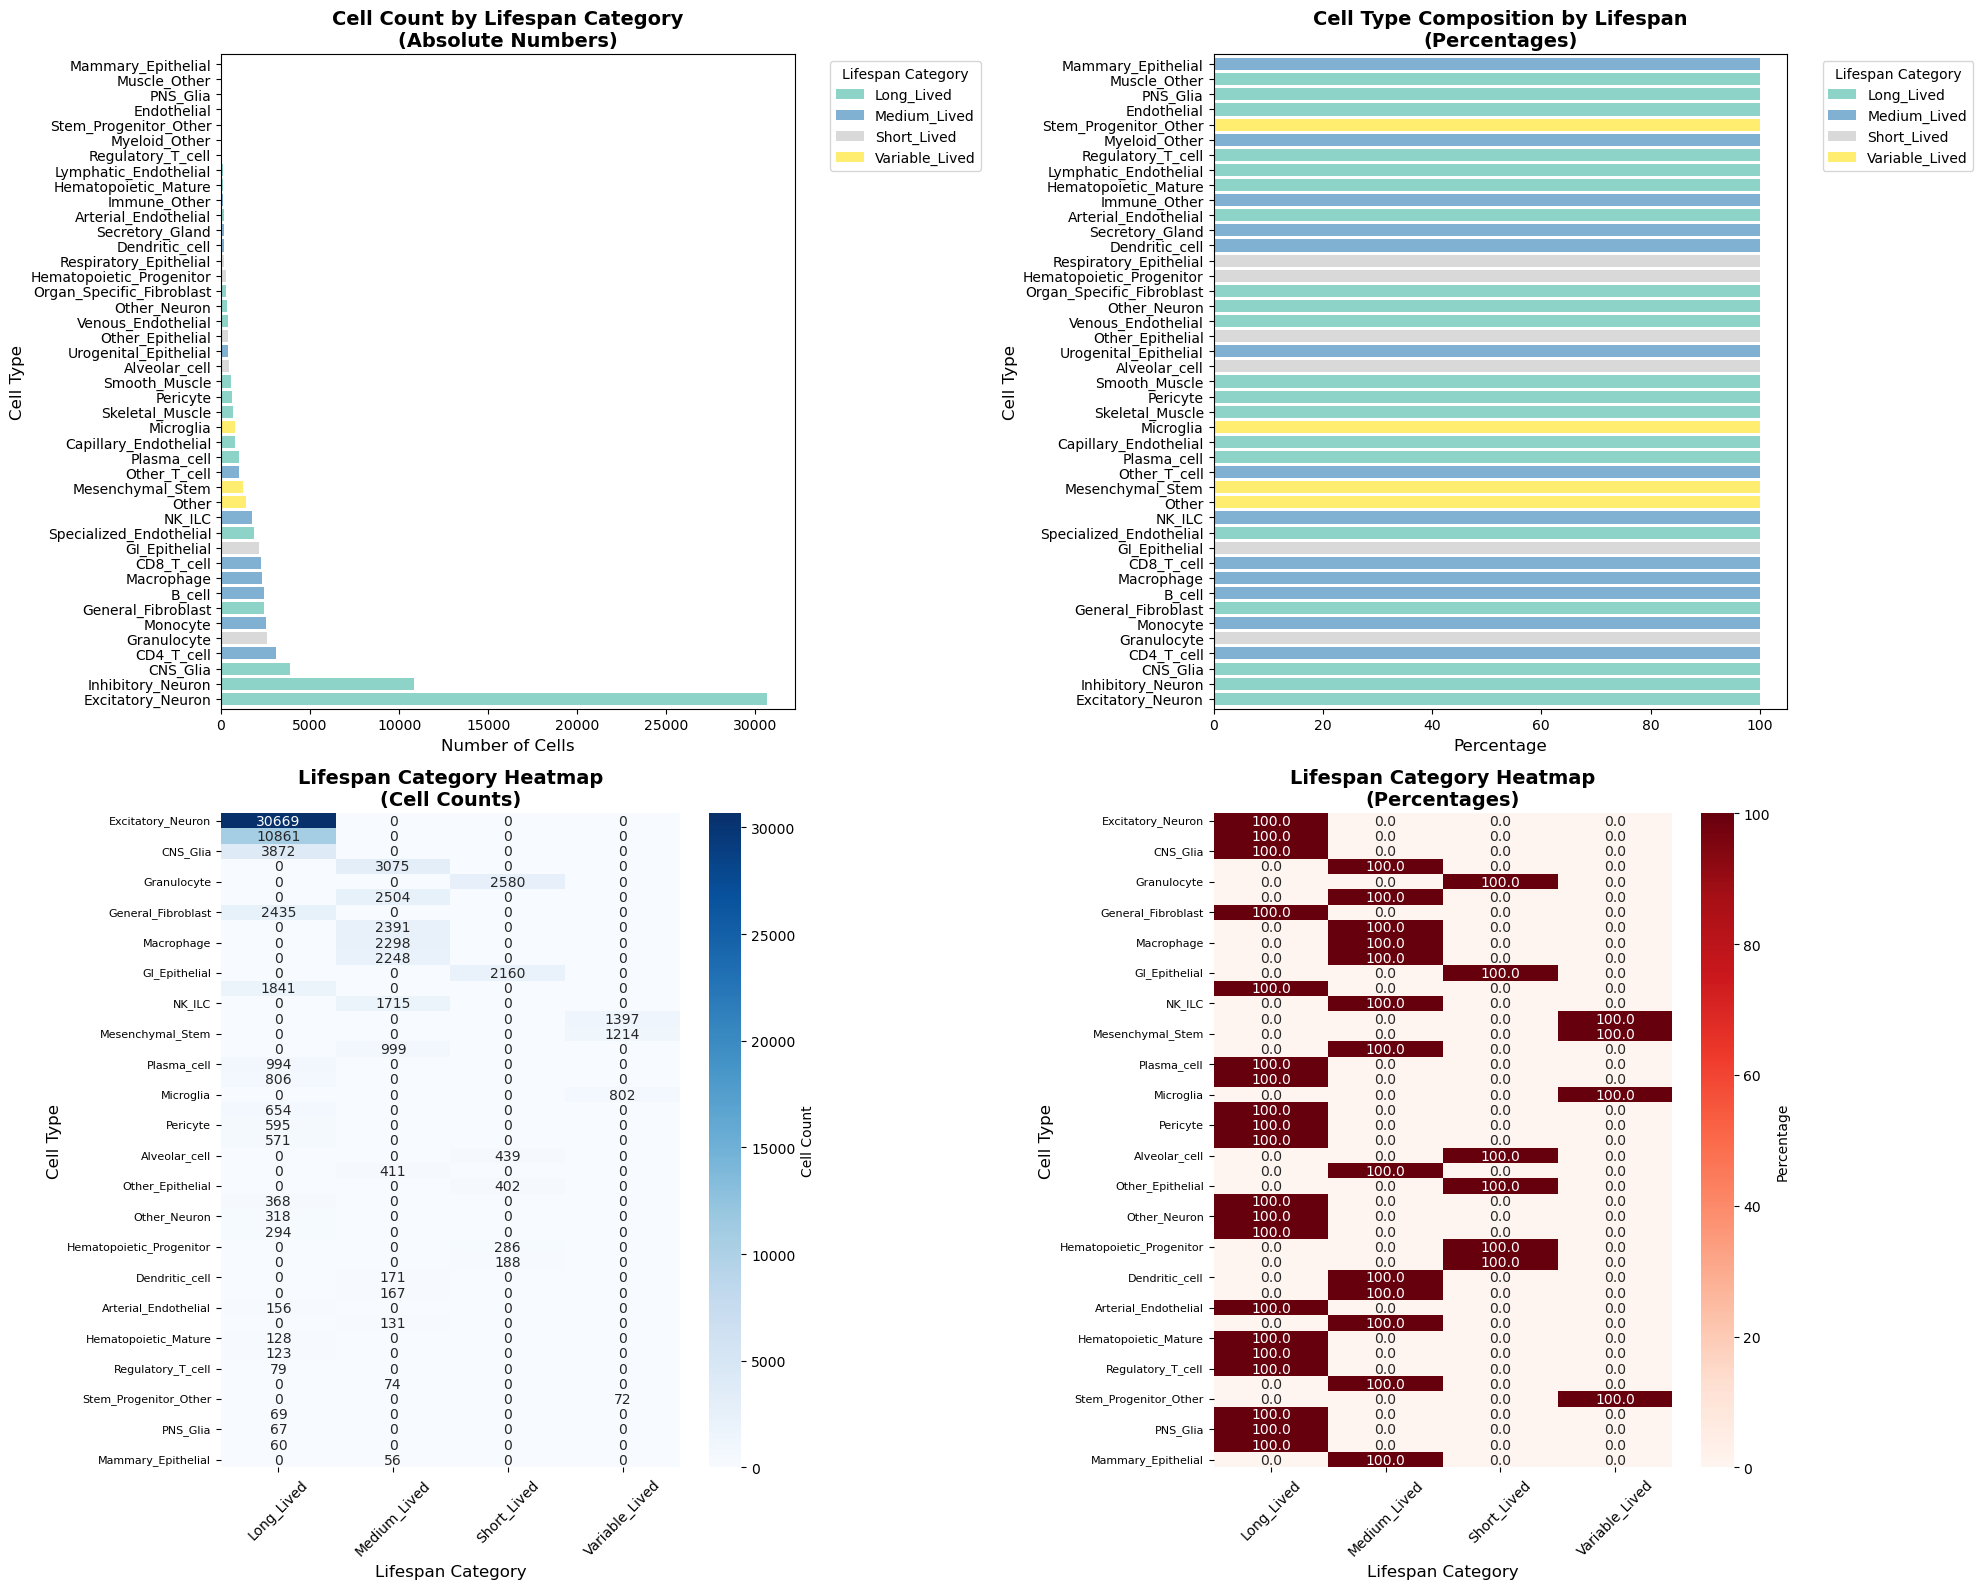


DETAILED BREAKDOWN BY LIFESPAN CATEGORY:

LONG_LIVED:
----------
Total cells: 54,960
Cell types (43):
  Excitatory_Neuron: 30,669 (55.8%)
  Inhibitory_Neuron: 10,861 (19.8%)
  CNS_Glia: 3,872 (7.0%)
  General_Fibroblast: 2,435 (4.4%)
  Specialized_Endothelial: 1,841 (3.3%)
  Plasma_cell: 994 (1.8%)
  Capillary_Endothelial: 806 (1.5%)
  Skeletal_Muscle: 654 (1.2%)
  Pericyte: 595 (1.1%)
  Smooth_Muscle: 571 (1.0%)
  Venous_Endothelial: 368 (0.7%)
  Other_Neuron: 318 (0.6%)
  Organ_Specific_Fibroblast: 294 (0.5%)
  Arterial_Endothelial: 156 (0.3%)
  Hematopoietic_Mature: 128 (0.2%)
  Lymphatic_Endothelial: 123 (0.2%)
  Regulatory_T_cell: 79 (0.1%)
  Endothelial: 69 (0.1%)
  PNS_Glia: 67 (0.1%)
  Muscle_Other: 60 (0.1%)
  Other: 0 (0.0%)
  Respiratory_Epithelial: 0 (0.0%)
  Secretory_Gland: 0 (0.0%)
  Stem_Progenitor_Other: 0 (0.0%)
  Other_T_cell: 0 (0.0%)
  Urogenital_Epithelial: 0 (0.0%)
  Other_Epithelial: 0 (0.0%)
  Alveolar_cell: 0 (0.0%)
  NK_ILC: 0 (0.0%)
  Myeloid_Other: 0 (0.0%

In [10]:
# Create breakdown visualization of lifespan vs broad cell types

# Create crosstab for the breakdown
lifespan_breakdown = pd.crosstab(filtered_splice_adata.obs['broad_cell_type'], 
                                filtered_splice_adata.obs['lifespan_category'])

# Sort by total cell count for better visualization
cell_type_totals = filtered_splice_adata.obs['broad_cell_type'].value_counts()
lifespan_breakdown = lifespan_breakdown.reindex(cell_type_totals.index)

print("Lifespan Category Breakdown by Cell Type:")
print(lifespan_breakdown)

# Calculate percentages for each cell type
lifespan_breakdown_pct = lifespan_breakdown.div(lifespan_breakdown.sum(axis=1), axis=0) * 100

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Stacked bar chart showing absolute counts
lifespan_breakdown.plot(kind='barh', stacked=True, ax=axes[0,0], 
                       colormap='Set3', width=0.8)
axes[0,0].set_title('Cell Count by Lifespan Category\n(Absolute Numbers)', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Number of Cells', fontsize=12)
axes[0,0].set_ylabel('Cell Type', fontsize=12)
axes[0,0].legend(title='Lifespan Category', bbox_to_anchor=(1.05, 1), loc='upper left')

# 2. Stacked bar chart showing percentages
lifespan_breakdown_pct.plot(kind='barh', stacked=True, ax=axes[0,1], 
                           colormap='Set3', width=0.8)
axes[0,1].set_title('Cell Type Composition by Lifespan\n(Percentages)', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Percentage', fontsize=12)
axes[0,1].set_ylabel('Cell Type', fontsize=12)
axes[0,1].legend(title='Lifespan Category', bbox_to_anchor=(1.05, 1), loc='upper left')

# 3. Heatmap of absolute counts
sns.heatmap(lifespan_breakdown, annot=True, fmt='d', cmap='Blues', 
            ax=axes[1,0], cbar_kws={'label': 'Cell Count'})
axes[1,0].set_title('Lifespan Category Heatmap\n(Cell Counts)', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Lifespan Category', fontsize=12)
axes[1,0].set_ylabel('Cell Type', fontsize=12)
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].tick_params(axis='y', rotation=0, labelsize=8)

# 4. Heatmap of percentages
sns.heatmap(lifespan_breakdown_pct, annot=True, fmt='.1f', cmap='Reds', 
            ax=axes[1,1], cbar_kws={'label': 'Percentage'})
axes[1,1].set_title('Lifespan Category Heatmap\n(Percentages)', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Lifespan Category', fontsize=12)
axes[1,1].set_ylabel('Cell Type', fontsize=12)
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.show()

# Print detailed breakdown for each lifespan category
print("\n" + "="*70)
print("DETAILED BREAKDOWN BY LIFESPAN CATEGORY:")
print("="*70)

for lifespan_cat in filtered_splice_adata.obs['lifespan_category'].unique():
    print(f"\n{lifespan_cat.upper()}:")
    print("-" * len(lifespan_cat))
    
    # Get cell types in this lifespan category
    cell_types_in_cat = filtered_splice_adata.obs[filtered_splice_adata.obs['lifespan_category'] == lifespan_cat]['broad_cell_type'].value_counts()
    total_in_cat = cell_types_in_cat.sum()
    
    print(f"Total cells: {total_in_cat:,}")
    print(f"Cell types ({len(cell_types_in_cat)}):")
    
    for cell_type, count in cell_types_in_cat.items():
        percentage = (count / total_in_cat) * 100
        print(f"  {cell_type}: {count:,} ({percentage:.1f}%)")

# Create summary statistics
print("\n" + "="*70)
print("LIFESPAN CATEGORY SUMMARY:")
print("="*70)

lifespan_summary = filtered_splice_adata.obs['lifespan_category'].value_counts()
total_cells = len(filtered_splice_adata.obs)

for category, count in lifespan_summary.items():
    percentage = (count / total_cells) * 100
    n_cell_types = len(filtered_splice_adata.obs[filtered_splice_adata.obs['lifespan_category'] == category]['broad_cell_type'].unique())
    print(f"{category}: {count:,} cells ({percentage:.1f}%) across {n_cell_types} cell types")

# Check for any potential misclassifications
print("\n" + "="*70)
print("QUALITY CHECK - Potential Misclassifications:")
print("="*70)

# Look for cell types that might be debatable
debatable_cases = {
    'Microglia': 'Variable_Lived',  # Can be long-lived but also replaced
    'Macrophage': 'Medium_Lived',   # Tissue macrophages can be long-lived
    'Plasma_cell': 'Long_Lived',    # Some are short-lived, some very long-lived
    'Regulatory_T_cell': 'Long_Lived'  # Memory T cells can be very long-lived
}

print(debatable_cases)

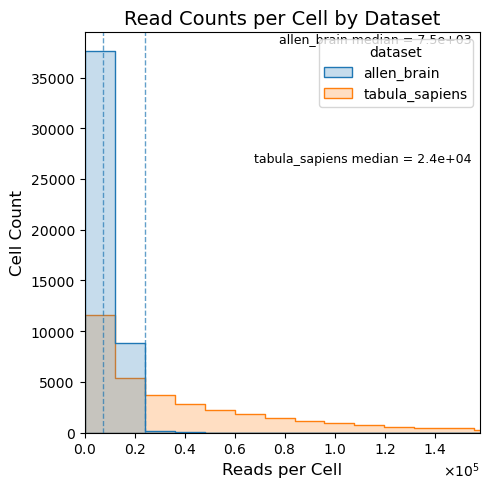

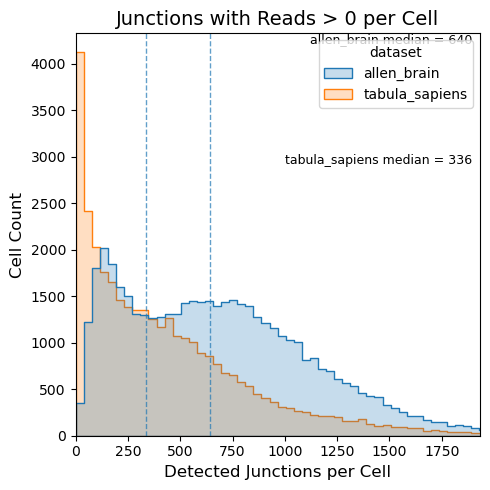

In [11]:
# Ensure correct matrix
cell_by_junction = splice_adata_full.layers["cell_by_junction_matrix"]
if not sp.issparse(cell_by_junction):
    cell_by_junction = sp.csr_matrix(cell_by_junction)

# Compute per-cell read counts
splice_adata_full.obs["reads_per_cell"] = np.ravel(cell_by_junction.sum(axis=1))

# Compute per-cell non-zero junction count
splice_adata_full.obs["junctions_detected_per_cell"] = np.ravel((cell_by_junction > 0).sum(axis=1))

# Compute per-junction read counts
splice_adata_full.var["reads_per_junction"] = np.ravel(cell_by_junction.sum(axis=0))

# === Plot 1: Reads per Cell by Dataset (with scientific notation) ===
plt.figure(figsize=(5, 5))
sns.histplot(data=splice_adata_full.obs, x="reads_per_cell", hue="dataset", bins=100,
             multiple="layer", element="step")
plt.title("Read Counts per Cell by Dataset", fontsize=14)
plt.xlabel("Reads per Cell", fontsize=12)
plt.ylabel("Cell Count", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, np.percentile(splice_adata_full.obs["reads_per_cell"], 99))

# Use scientific notation on x-axis
ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# Add median lines + labels
ylim = plt.ylim()
line_spacing = (ylim[1] * 0.9) / (len(splice_adata_full.obs["dataset"].unique()) + 1)
for i, ds in enumerate(sorted(splice_adata_full.obs["dataset"].unique())):
    median_val = splice_adata_full.obs.loc[splice_adata_full.obs["dataset"] == ds, "reads_per_cell"].median()
    plt.axvline(median_val, linestyle="--", linewidth=1, alpha=0.7)
    plt.text(plt.xlim()[1] * 0.98, ylim[1] - i * line_spacing,
             f"{ds} median = {int(median_val):.1e}",
             ha="right", va="top", fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/reads_per_cell_by_dataset.pdf")

# === Plot 2: Junctions Detected per Cell ===
plt.figure(figsize=(5, 5))
sns.histplot(data=splice_adata_full.obs, x="junctions_detected_per_cell", hue="dataset", bins=100,
             multiple="layer", element="step")
plt.title("Junctions with Reads > 0 per Cell", fontsize=14)
plt.xlabel("Detected Junctions per Cell", fontsize=12)
plt.ylabel("Cell Count", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, np.percentile(splice_adata_full.obs["junctions_detected_per_cell"], 99))

ylim = plt.ylim()
line_spacing = (ylim[1] * 0.9) / (len(splice_adata_full.obs["dataset"].unique()) + 1)
for i, ds in enumerate(sorted(splice_adata_full.obs["dataset"].unique())):
    median_val = splice_adata_full.obs.loc[splice_adata_full.obs["dataset"] == ds, "junctions_detected_per_cell"].median()
    plt.axvline(median_val, linestyle="--", linewidth=1, alpha=0.7)
    plt.text(plt.xlim()[1] * 0.98, ylim[1] - i * line_spacing,
             f"{ds} median = {int(median_val)}",
             ha="right", va="top", fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/junctions_per_cell_by_dataset.pdf")

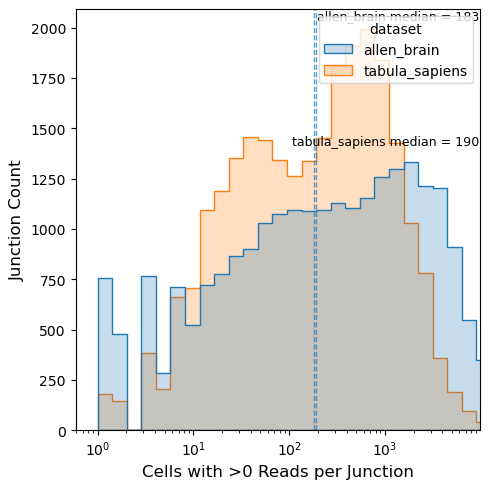

In [12]:
# Step 1: Extract matrix and metadata
cell_by_junction = splice_adata_full.layers["cell_by_junction_matrix"]
if not sp.issparse(cell_by_junction):
    cell_by_junction = sp.csr_matrix(cell_by_junction)

datasets = splice_adata_full.obs["dataset"].unique()
results = []

# Step 2: For each dataset, compute per-junction detection
for ds in sorted(datasets):
    idx = np.where(splice_adata_full.obs["dataset"] == ds)[0]
    submat = cell_by_junction[idx, :]
    counts = np.array((submat > 0).sum(axis=0)).ravel()
    results.append(pd.DataFrame({
        "dataset": ds,
        "cells_per_junction": counts
    }))

# Step 3: Concatenate results
df_cells_per_junction = pd.concat(results, ignore_index=True)

# === Plot 3B: Cells per Junction by Dataset ===
plt.figure(figsize=(5, 5))
sns.histplot(
    data=df_cells_per_junction,
    x="cells_per_junction",
    hue="dataset",
    bins=30,
    multiple="layer",
    element="step",
    log_scale=(True, False)  # log-scale on x-axis only
)

plt.xlabel("Cells with >0 Reads per Junction", fontsize=12)
plt.ylabel("Junction Count", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, np.percentile(df_cells_per_junction["cells_per_junction"], 99))

# Add median lines + labels per dataset
ylim = plt.ylim()
line_spacing = (ylim[1] * 0.9) / (len(datasets) + 1)
for i, ds in enumerate(sorted(datasets)):
    median_val = df_cells_per_junction.loc[df_cells_per_junction["dataset"] == ds, "cells_per_junction"].median()
    plt.axvline(median_val, linestyle="--", linewidth=1, alpha=0.7)
    plt.text(plt.xlim()[1] * 0.98, ylim[1] - i * line_spacing,
             f"{ds} median = {int(median_val)}",
             ha="right", va="top", fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/cells_per_junction_by_dataset.pdf")


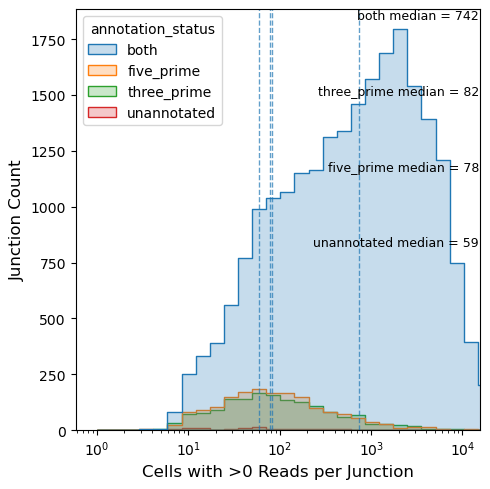

In [13]:
cell_by_junction = splice_adata_full.layers["cell_by_junction_matrix"]
if not sp.issparse(cell_by_junction):
    cell_by_junction = sp.csr_matrix(cell_by_junction)

# Number of cells each junction is detected in (i.e., >0 reads)
splice_adata_full.var["cells_per_junction"] = np.ravel((cell_by_junction > 0).sum(axis=0))
df_junc = splice_adata_full.var[["cells_per_junction", "annotation_status"]].copy()
summary = (
    df_junc.groupby("annotation_status", observed=True)["cells_per_junction"]
    .median()
    .sort_values(ascending=False)
    .reset_index(name="median_cells")
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 5))
sns.histplot(
    data=df_junc,
    x="cells_per_junction",
    hue="annotation_status",
    bins=30,
    multiple="layer",
    element="step",
    log_scale=(True, False)
)

plt.xlabel("Cells with >0 Reads per Junction", fontsize=12)
plt.ylabel("Junction Count", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, np.percentile(df_junc["cells_per_junction"], 99))

# Add vertical lines + text for medians
ylim = plt.ylim()
line_spacing = (ylim[1] * 0.9) / (len(summary) + 1)
for i, row in summary.iterrows():
    plt.axvline(row["median_cells"], linestyle="--", linewidth=1, alpha=0.7)
    plt.text(
        plt.xlim()[1] * 0.98,
        ylim[1] - i * line_spacing,
        f"{row['annotation_status']} median = {int(row['median_cells'])}",
        ha="right", va="top", fontsize=9
    )

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/cells_per_junction_by_annotation_status.pdf")
plt.show()

## Rename factors to be in order that matches PI

In [14]:
filtered_splice_adata, pi

(AnnData object with n_obs × n_vars = 80740 × 25909
     obs: 'cell_id', 'donor', 'sex', 'age', 'dataset', 'tissue', 'cell_type', 'broad_cell_type', 'cell_id_index', 'cell_id_clean', 'AgingScore_unweighted', 'AgingScore_pos', 'AgingScore_neg', 'nuclear_ratio_log_norm', 'seqtech', 'age_numeric', 'age_group', 'cell_type_module', 'functional_category', 'tissue_system', 'lifespan_category', 'simple_category', 'senescence_proneness'
     var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'clean_gene_id', 'gene_name', 'mean_transcript_length', 'mean_intron_length', 'num_transcripts', 'transcript_biotypes', 'n_cells_by_counts', 'mean_counts', 'junction_conserved', 'non_zero_count_cells', 'non_zero_cell_prop', 'total_read_counts', 'mean_counts_per_cell', 'junction_variability', 'annotation_status_score', 'expression_breadth_score', 'read_count_score', 'variability_score', 'conservation_s

In [15]:
# Get new factor order (indices sorted by decreasing PI)
new_order = np.argsort(-pi)  # minus for descending sort

# Reorder X_PHI (cell × K)
filtered_splice_adata.obsm["X_PHI"] = filtered_splice_adata.obsm["X_PHI"][:, new_order]

# Reorder psi_learned (junction × K)
filtered_splice_adata.varm["psi_learned"] = filtered_splice_adata.varm["psi_learned"][:, new_order]

In [16]:
# Number of factors (K)
K = filtered_splice_adata.obsm["X_PHI"].shape[1]

# Generate column names: Factor_1, Factor_2, ..., Factor_K
phi_colnames = [f"Factor_{i+1}" for i in range(K)]

# Create a DataFrame from X_PHI
phi_df = pd.DataFrame(
    filtered_splice_adata.obsm["X_PHI"], 
    index=filtered_splice_adata.obs_names,
    columns=phi_colnames
)

# Merge with adata.obs
# This will add K new columns to adata.obs
filtered_splice_adata.obs = pd.concat([filtered_splice_adata.obs, phi_df], axis=1)

In [17]:
filtered_splice_adata.obs

,cell_id,donor,sex,age,dataset,tissue,cell_type,broad_cell_type,cell_id_index,cell_id_clean,...,Factor_15,Factor_16,Factor_17,Factor_18,Factor_19,Factor_20,Factor_21,Factor_22,Factor_23,Factor_24
cell_id_clean,,,,,,,,,,,,,,,,,,,,,
F1S4_160106_001_B01,F1S4_160106_001_B01,H200.1030,male,54,allen_brain,MTG,SST,Inhibitory_Neuron,0,F1S4_160106_001_B01,...,0.003839,0.016691,0.005337,0.004854,0.007450,0.003377,0.003422,0.004599,0.002112,0.000803
F1S4_160106_001_D01,F1S4_160106_001_D01,H200.1030,male,54,allen_brain,MTG,IT,Excitatory_Neuron,1,F1S4_160106_001_D01,...,0.005045,0.005094,0.002187,0.004079,0.001348,0.003602,0.001517,0.002077,0.002101,0.001161
F1S4_160106_001_E01,F1S4_160106_001_E01,H200.1030,male,54,allen_brain,MTG,L6 CT,Excitatory_Neuron,2,F1S4_160106_001_E01,...,0.003738,0.006461,0.002810,0.004644,0.001678,0.004218,0.001660,0.002447,0.002138,0.001216
F1S4_160106_001_G01,F1S4_160106_001_G01,H200.1030,male,54,allen_brain,MTG,L6b,Excitatory_Neuron,3,F1S4_160106_001_G01,...,0.003437,0.005491,0.003903,0.004072,0.009464,0.004995,0.006075,0.001216,0.001520,0.002649
F1S4_160106_001_H01,F1S4_160106_001_H01,H200.1030,male,54,allen_brain,MTG,IT,Excitatory_Neuron,4,F1S4_160106_001_H01,...,0.003464,0.005423,0.001875,0.001714,0.001521,0.001937,0.002203,0.000762,0.001038,0.002009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSP8_donor_B134141_M3_B134697_M3_Prostate_Immune,TSP8_donor_B134141_M3_B134697_M3_Prostate_Immune,TSP8,male,56,tabula_sapiens,Prostate,smooth muscle cell,Smooth_Muscle,80775,TSP8_donor_B134141_M3_B134697_M3_Prostate_Immune,...,0.011370,0.014643,0.027424,0.022511,0.010192,0.021831,0.006942,0.016975,0.005302,0.008705
TSP8_donor_B134141_M8_B134697_M8_Prostate_Immune,TSP8_donor_B134141_M8_B134697_M8_Prostate_Immune,TSP8,male,56,tabula_sapiens,Prostate,luminal epithelial cell,Mammary_Epithelial,80776,TSP8_donor_B134141_M8_B134697_M8_Prostate_Immune,...,0.022208,0.016773,0.021521,0.018928,0.019280,0.015360,0.019159,0.016001,0.020159,0.010114
TSP8_donor_B134141_N20_B134697_N20_Prostate_Immune,TSP8_donor_B134141_N20_B134697_N20_Prostate_Im...,TSP8,male,56,tabula_sapiens,Prostate,luminal epithelial cell,Mammary_Epithelial,80777,TSP8_donor_B134141_N20_B134697_N20_Prostate_Im...,...,0.031932,0.016752,0.017430,0.017429,0.012652,0.011851,0.009201,0.009769,0.017473,0.026238


### Back to looking at model results

In [18]:
def analyze_median_nonzero_activity_by_group(adata, groupby_column, output_suffix=None,
                                            reference_clustermap=None, use_reference_order=True,
                                            figsize=(6, 8), cmap="PRGn", center=0,
                                            zero_threshold=0, cluster_rows=True, cluster_cols=True):
    """
    Flexible function to analyze median nonzero factor activity by any grouping variable
    
    Parameters:
    -----------
    adata : AnnData
        Contains X_PHI and obs data
    groupby_column : str
        Column name to group by (e.g., 'simple_category', 'broad_cell_type', 'lifespan_category')
    output_suffix : str, optional
        Custom suffix for output files. If None, uses groupby_column name
    reference_clustermap : ClusterGrid, optional
        Reference clustermap to use for ordering (e.g., from previous analysis)
    use_reference_order : bool
        Whether to use reference clustermap ordering if available
    figsize : tuple
        Figure size for clustermap
    cmap : str
        Colormap for clustermap
    center : float
        Center value for colormap
    zero_threshold : float
        Values <= this threshold are considered "zero" and excluded from median calculation
    cluster_rows, cluster_cols : bool
        Whether to cluster rows/columns (ignored if using reference order)
    
    Returns:
    --------
    median_nonzero : DataFrame
        Matrix of median nonzero factor activities by group
    g : ClusterGrid
        Seaborn clustermap object
    """
    
    # Set output suffix
    if output_suffix is None:
        output_suffix = groupby_column.replace('_', '_')
    
    print(f"Analyzing median nonzero factor activity by: {groupby_column}")
    print(f"Output suffix: {output_suffix}")
    print(f"Zero threshold: {zero_threshold}")
    
    # Extract PHI matrix
    X_PHI = adata.obsm["X_PHI"]
    n_factors = X_PHI.shape[1]
    factor_cols = [f"Factor_{i+1}" for i in range(n_factors)]
    
    # Build DataFrame
    df_all = pd.DataFrame(X_PHI, columns=factor_cols)
    df_all[groupby_column] = adata.obs[groupby_column].values
    
    print(f"Data shape: {df_all.shape}")
    print(f"Groups in {groupby_column}: {df_all[groupby_column].nunique()}")
    print(f"Unique groups: {sorted(df_all[groupby_column].unique())}")
    
    # Set values <= threshold to NaN to ignore them in median calculation
    df_all_nonzero = df_all.copy()
    df_all_nonzero[factor_cols] = df_all_nonzero[factor_cols].mask(df_all_nonzero[factor_cols] <= zero_threshold)
    
    # Compute median nonzero activity for each group and factor
    median_nonzero = df_all_nonzero.groupby(groupby_column, observed=True)[factor_cols].median()
    median_nonzero = median_nonzero.fillna(0)  # Fill NaN with 0 (groups with no nonzero values)
    
    print(f"Median nonzero matrix shape: {median_nonzero.shape}")
    print(f"Value range: {median_nonzero.values.min():.3f} to {median_nonzero.values.max():.3f}")
    
    # Handle ordering
    if use_reference_order and reference_clustermap is not None:
        try:
            # Try to use reference clustermap ordering
            print("Using reference clustermap ordering...")
            
            # Get reference ordering
            ref_row_order = [median_nonzero.index[i] for i in reference_clustermap.dendrogram_row.reordered_ind 
                           if i < len(median_nonzero.index)]
            ref_col_order = [median_nonzero.columns[i] for i in reference_clustermap.dendrogram_col.reordered_ind 
                           if i < len(median_nonzero.columns)]
            
            # Apply ordering if we have valid indices
            if len(ref_row_order) > 0 and len(ref_col_order) > 0:
                # Only reorder rows/columns that exist in current data
                available_rows = [row for row in ref_row_order if row in median_nonzero.index]
                available_cols = [col for col in ref_col_order if col in median_nonzero.columns]
                
                if len(available_rows) > 0:
                    median_nonzero = median_nonzero.loc[available_rows, :]
                if len(available_cols) > 0:
                    median_nonzero = median_nonzero.loc[:, available_cols]
                
                # Don't cluster if using reference order
                cluster_rows = False
                cluster_cols = False
                print(f"Applied reference ordering: {len(available_rows)} rows, {len(available_cols)} cols")
            else:
                print("Reference ordering not applicable, will cluster normally")
                
        except Exception as e:
            print(f"Could not apply reference ordering: {e}")
            print("Will cluster normally")
    
    # Create clustermap
    g = sns.clustermap(
        median_nonzero,
        cmap=cmap,
        center=center,
        figsize=figsize,
        xticklabels=True,
        yticklabels=True,
        cbar_kws={'label': 'Median Factor Activity (nonzero)'},
        row_cluster=cluster_rows,
        col_cluster=cluster_cols,
        linewidths=0.2,
        linecolor='gray'
    )
    
    # Format labels
    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right', fontsize=8)
    plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)
    g.ax_cbar.set_ylabel("Median Nonzero\nFactor Activity", fontsize=10)
    g.ax_cbar.tick_params(labelsize=8)
    
    # Add title
    title = f"Median Nonzero Factor Activity by {groupby_column.replace('_', ' ').title()}"
    g.fig.suptitle(title, fontsize=12, y=0.98)
    
    # Save with flexible filename
    filename = f"median_nonzero_factor_activity_by_{output_suffix}.pdf"
    filepath = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(filepath, format="pdf", bbox_inches='tight', dpi=300)
    print(f"Saved: {filename}")
    
    plt.show()
    
    # Save data
    csv_filename = f"median_nonzero_factor_activity_by_{output_suffix}.csv"
    median_nonzero.to_csv(os.path.join(OUTPUT_DIR, csv_filename))
    print(f"Saved: {csv_filename}")
    
    # Print summary statistics
    print(f"\nSummary Statistics:")
    print(f"  Groups with data: {len(median_nonzero)}")
    print(f"  Factors analyzed: {len(median_nonzero.columns)}")
    print(f"  Non-zero entries: {(median_nonzero > 0).sum().sum()}")
    print(f"  Total entries: {median_nonzero.size}")
    print(f"  Sparsity: {((median_nonzero == 0).sum().sum() / median_nonzero.size * 100):.1f}% zeros")
    
    # Show top active factors per group
    print(f"\nTop active factor per group:")
    for group in median_nonzero.index:
        top_factor = median_nonzero.loc[group].idxmax()
        top_value = median_nonzero.loc[group].max()
        print(f"  {group}: {top_factor} ({top_value:.3f})")
    
    return median_nonzero, g

# Flexible age delta analysis function
def analyze_age_delta_by_group(adata, groupby_column, output_suffix=None, 
                              age_column="age_group", young_label="young", old_label="old",
                              figsize=(6, 8), cmap="BrBG"):
    """
    Flexible function to analyze age-related factor changes by any grouping variable
    
    Parameters:
    -----------
    adata : AnnData
        Contains X_PHI and obs data
    groupby_column : str
        Column name to group by (e.g., 'simple_category', 'broad_cell_type', 'lifespan_category')
    output_suffix : str, optional
        Custom suffix for output files. If None, uses groupby_column name
    age_column : str
        Column containing age groups
    young_label, old_label : str
        Labels for young and old groups in age_column
    figsize : tuple
        Figure size for clustermap
    cmap : str
        Colormap for clustermap
    
    Returns:
    --------
    delta_median : DataFrame
        Matrix of age-related changes (old - young) by group and factor
    g : ClusterGrid
        Seaborn clustermap object
    """
    
    # Set output suffix
    if output_suffix is None:
        output_suffix = groupby_column.replace('_', '_')
    
    print(f"Analyzing age delta by: {groupby_column}")
    print(f"Output suffix: {output_suffix}")
    
    # Extract PHI matrix
    X_PHI = adata.obsm["X_PHI"]
    n_factors = X_PHI.shape[1]
    factor_cols = [f"factor_{i}" for i in range(n_factors)]
    
    # Build DataFrame
    df_all = pd.DataFrame(X_PHI, columns=factor_cols)
    df_all[groupby_column] = adata.obs[groupby_column].values
    df_all[age_column] = adata.obs[age_column].values
    
    print(f"Data shape: {df_all.shape}")
    print(f"Groups in {groupby_column}: {df_all[groupby_column].nunique()}")
    print(f"Age groups: {df_all[age_column].unique()}")
    
    # Group by groupby_column + age_column
    median_by_group_and_age = df_all.groupby([groupby_column, age_column], observed=True)[factor_cols].median()
    
    # Check which age groups are available
    available_age_groups = median_by_group_and_age.index.get_level_values(age_column).unique()
    
    if young_label not in available_age_groups:
        print(f"Warning: '{young_label}' not found in age groups: {available_age_groups}")
        return None, None
    
    if old_label not in available_age_groups:
        print(f"Warning: '{old_label}' not found in age groups: {available_age_groups}")
        return None, None
    
    # Pivot into two matrices: one for young, one for old
    try:
        median_young = median_by_group_and_age.xs(young_label, level=age_column)
        median_old = median_by_group_and_age.xs(old_label, level=age_column)
    except KeyError as e:
        print(f"Error extracting age groups: {e}")
        print(f"Available combinations:")
        print(median_by_group_and_age.index)
        return None, None
    
    # Align indices and calculate delta
    common_groups = median_young.index.intersection(median_old.index)
    print(f"Groups with both young and old data: {len(common_groups)}")
    
    if len(common_groups) == 0:
        print("No groups have both young and old data!")
        return None, None
    
    median_young_aligned = median_young.loc[common_groups]
    median_old_aligned = median_old.loc[common_groups]
    
    # Calculate delta: old - young
    delta_median = median_old_aligned - median_young_aligned
    delta_median = delta_median.fillna(0)
    
    print(f"Delta matrix shape: {delta_median.shape}")
    print(f"Delta range: {delta_median.values.min():.3f} to {delta_median.values.max():.3f}")
    
    # Create clustermap
    g = sns.clustermap(
        delta_median,
        cmap=cmap,
        center=0,
        figsize=figsize,
        xticklabels=True,
        yticklabels=True,
        cbar_kws={'label': f'Δ({old_label} - {young_label})'},
        linewidths=0.2,
        linecolor='gray',
        row_cluster=True,
        col_cluster=True
    )
    
    # Format labels
    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right', fontsize=8)
    plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)
    g.ax_cbar.set_ylabel(f"Δ({old_label} - {young_label})", fontsize=10)
    g.ax_cbar.tick_params(labelsize=8)
    
    # Add title
    title = f"Age-Related Factor Changes by {groupby_column.replace('_', ' ').title()}"
    g.fig.suptitle(title, fontsize=12, y=0.98)
    
    # Save with flexible filename
    filename = f"delta_median_{old_label}_minus_{young_label}_by_{output_suffix}.pdf"
    filepath = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(filepath, format="pdf", bbox_inches='tight', dpi=300)
    print(f"Saved: {filename}")
    
    plt.show()
    
    # Save data
    csv_filename = f"delta_median_{old_label}_minus_{young_label}_by_{output_suffix}.csv"
    delta_median.to_csv(os.path.join(OUTPUT_DIR, csv_filename))
    print(f"Saved: {csv_filename}")
    return delta_median, g

RUNNING AGE DELTA ANALYSIS BY DIFFERENT GROUPINGS

1. Analysis by Simple Category:
Analyzing age delta by: simple_category
Output suffix: simple_category
Data shape: (80740, 26)
Groups in simple_category: 7
Age groups: ['old', 'young']
Categories (2, object): ['old', 'young']
Groups with both young and old data: 7
Delta matrix shape: (7, 24)
Delta range: -0.077 to 0.131
Saved: delta_median_old_minus_young_by_simple_category.pdf


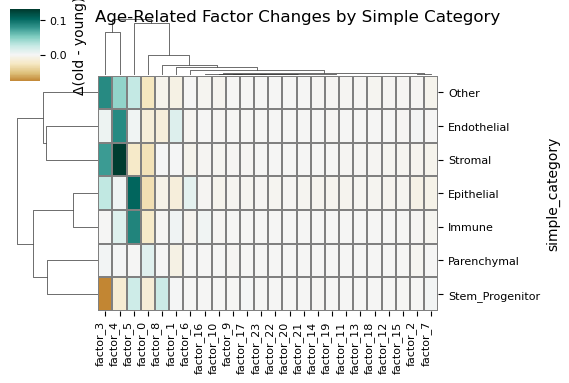

Saved: delta_median_old_minus_young_by_simple_category.csv


In [19]:
# Example usage with different grouping variables
print("="*60)
print("RUNNING AGE DELTA ANALYSIS BY DIFFERENT GROUPINGS")
print("="*60)

# 1. By simple category (your original request)
print("\n1. Analysis by Simple Category:")
delta_simple, g_simple = analyze_age_delta_by_group(
    filtered_splice_adata, 
    groupby_column='simple_category',
    figsize=(6, 4)
)


2. Analysis by Broad Cell Type:
Analyzing age delta by: broad_cell_type
Output suffix: broad_cell_type
Data shape: (80740, 26)
Groups in broad_cell_type: 43
Age groups: ['old', 'young']
Categories (2, object): ['old', 'young']
Groups with both young and old data: 40
Delta matrix shape: (40, 24)
Delta range: -0.276 to 0.179
Saved: delta_median_old_minus_young_by_broad_cell_type.pdf


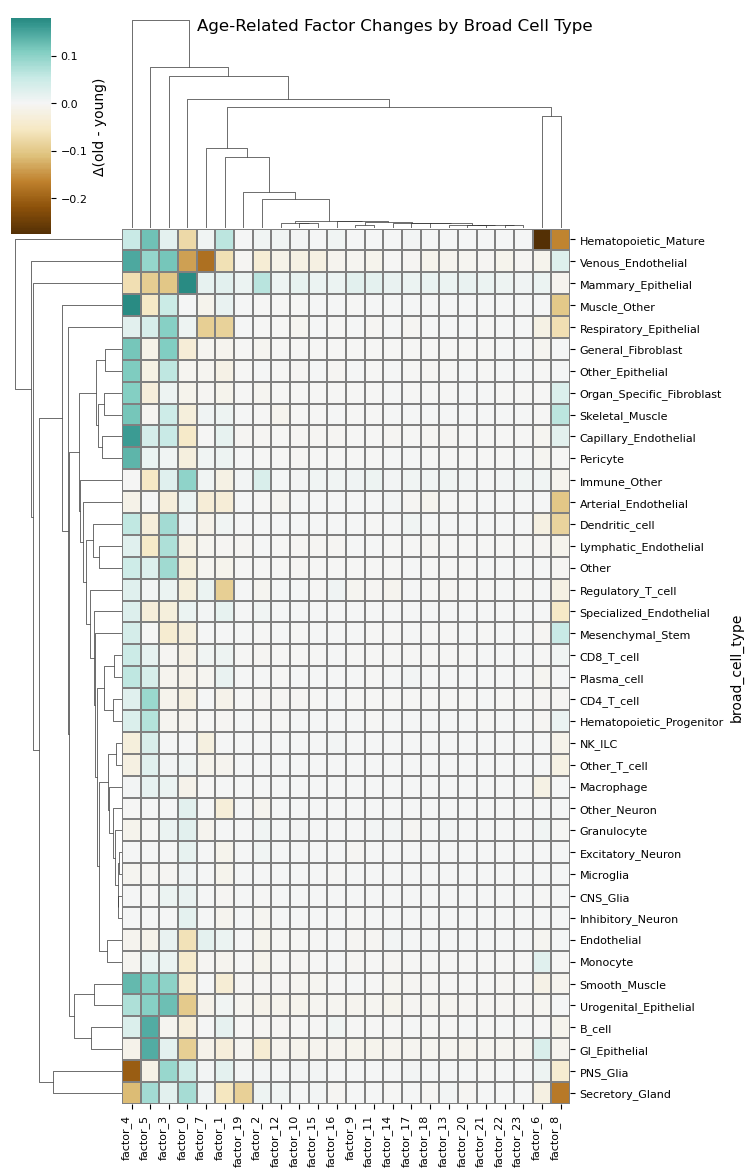

Saved: delta_median_old_minus_young_by_broad_cell_type.csv

3. Analysis by Lifespan Category:
Analyzing age delta by: lifespan_category
Output suffix: lifespan_category
Data shape: (80740, 26)
Groups in lifespan_category: 4
Age groups: ['old', 'young']
Categories (2, object): ['old', 'young']
Groups with both young and old data: 4
Delta matrix shape: (4, 24)
Delta range: -0.065 to 0.058
Saved: delta_median_old_minus_young_by_lifespan_category.pdf


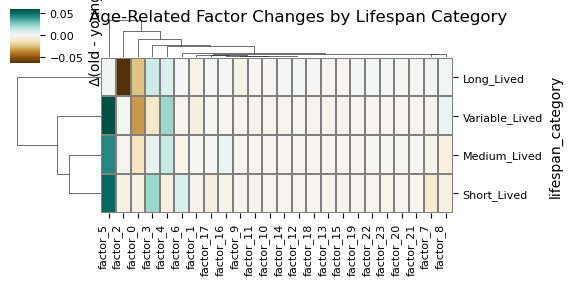

Saved: delta_median_old_minus_young_by_lifespan_category.csv

4. Analysis by Senescence Proneness:
Analyzing age delta by: senescence_proneness
Output suffix: senescence_proneness
Data shape: (80740, 26)
Groups in senescence_proneness: 4
Age groups: ['old', 'young']
Categories (2, object): ['old', 'young']
Groups with both young and old data: 4
Delta matrix shape: (4, 24)
Delta range: -0.150 to 0.142
Saved: delta_median_old_minus_young_by_senescence_proneness.pdf


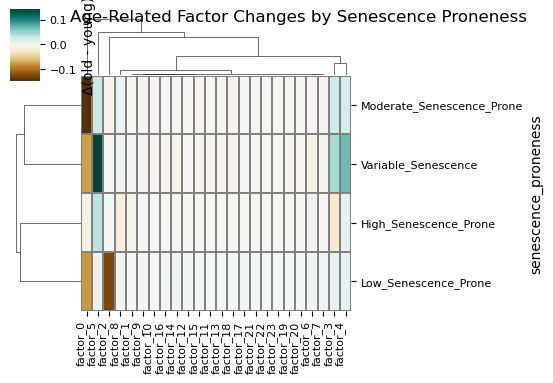

Saved: delta_median_old_minus_young_by_senescence_proneness.csv

5. Analysis by Functional Category:
Analyzing age delta by: functional_category
Output suffix: functional_category
Data shape: (80740, 26)
Groups in functional_category: 9
Age groups: ['old', 'young']
Categories (2, object): ['old', 'young']
Groups with both young and old data: 9
Delta matrix shape: (9, 24)
Delta range: -0.177 to 0.109
Saved: delta_median_old_minus_young_by_functional_category.pdf


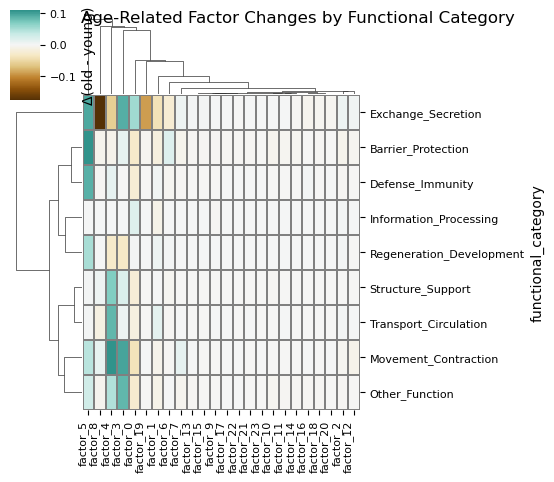

Saved: delta_median_old_minus_young_by_functional_category.csv


In [20]:


# 2. By broad cell type (original detailed analysis)
print("\n2. Analysis by Broad Cell Type:")
delta_broad, g_broad = analyze_age_delta_by_group(
    filtered_splice_adata,
    groupby_column='broad_cell_type', 
    figsize=(8, 12)
)

# 3. By lifespan category (interesting for aging biology)
print("\n3. Analysis by Lifespan Category:")
delta_lifespan, g_lifespan = analyze_age_delta_by_group(
    filtered_splice_adata,
    groupby_column='lifespan_category',
    figsize=(6, 3)
)

# 4. By senescence proneness (new!)
print("\n4. Analysis by Senescence Proneness:")
delta_senescence, g_senescence = analyze_age_delta_by_group(
    filtered_splice_adata,
    groupby_column='senescence_proneness',
    figsize=(6, 4)
)

# 5. By functional category
print("\n5. Analysis by Functional Category:")
delta_functional_cat, g_senescence_functional_cat = analyze_age_delta_by_group(
    filtered_splice_adata,
    groupby_column='functional_category',
    figsize=(6, 5)
)

RUNNING MEDIAN NONZERO FACTOR ACTIVITY ANALYSES

1. Analysis by Simple Category:
Analyzing median nonzero factor activity by: simple_category
Output suffix: simple_category
Zero threshold: 0
Data shape: (80740, 25)
Groups in simple_category: 7
Unique groups: ['Endothelial', 'Epithelial', 'Immune', 'Other', 'Parenchymal', 'Stem_Progenitor', 'Stromal']
Median nonzero matrix shape: (7, 24)
Value range: 0.002 to 0.526
Saved: median_nonzero_factor_activity_by_simple_category.pdf


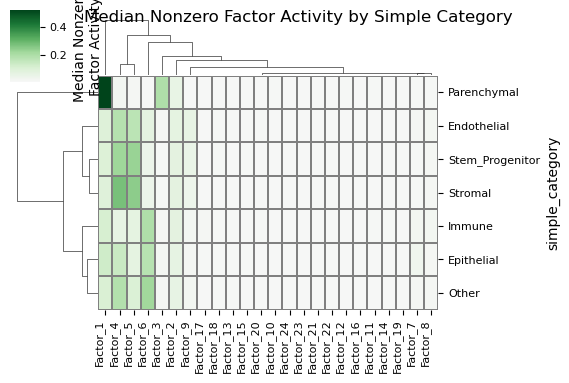

Saved: median_nonzero_factor_activity_by_simple_category.csv

Summary Statistics:
  Groups with data: 7
  Factors analyzed: 24
  Non-zero entries: 168
  Total entries: 168
  Sparsity: 0.0% zeros

Top active factor per group:
  Endothelial: Factor_4 (0.179)
  Epithelial: Factor_6 (0.177)
  Immune: Factor_6 (0.192)
  Other: Factor_6 (0.215)
  Parenchymal: Factor_1 (0.526)
  Stem_Progenitor: Factor_5 (0.230)
  Stromal: Factor_4 (0.273)

2. Analysis by Broad Cell Type:
Analyzing median nonzero factor activity by: broad_cell_type
Output suffix: broad_cell_type
Zero threshold: 0
Data shape: (80740, 25)
Groups in broad_cell_type: 43
Unique groups: ['Alveolar_cell', 'Arterial_Endothelial', 'B_cell', 'CD4_T_cell', 'CD8_T_cell', 'CNS_Glia', 'Capillary_Endothelial', 'Dendritic_cell', 'Endothelial', 'Excitatory_Neuron', 'GI_Epithelial', 'General_Fibroblast', 'Granulocyte', 'Hematopoietic_Mature', 'Hematopoietic_Progenitor', 'Immune_Other', 'Inhibitory_Neuron', 'Lymphatic_Endothelial', 'Macrophage'

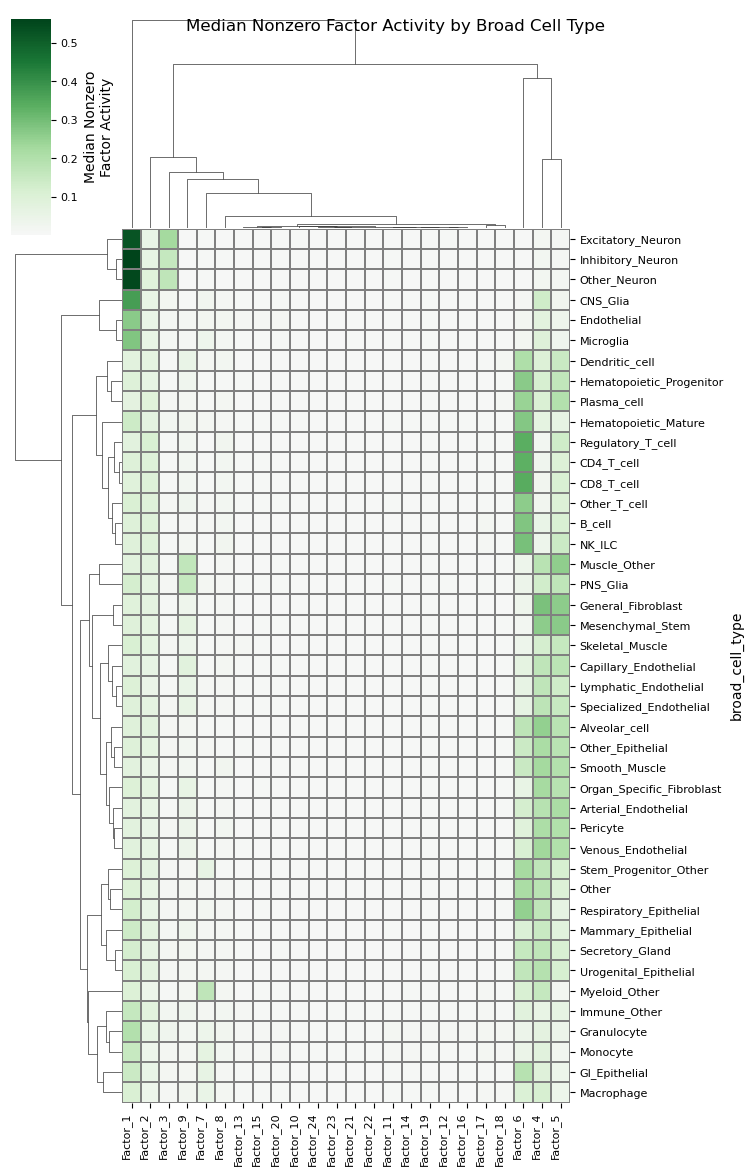

Saved: median_nonzero_factor_activity_by_broad_cell_type.csv

Summary Statistics:
  Groups with data: 43
  Factors analyzed: 24
  Non-zero entries: 1032
  Total entries: 1032
  Sparsity: 0.0% zeros

Top active factor per group:
  Alveolar_cell: Factor_4 (0.255)
  Arterial_Endothelial: Factor_5 (0.215)
  B_cell: Factor_6 (0.279)
  CD4_T_cell: Factor_6 (0.333)
  CD8_T_cell: Factor_6 (0.340)
  CNS_Glia: Factor_1 (0.373)
  Capillary_Endothelial: Factor_5 (0.180)
  Dendritic_cell: Factor_6 (0.206)
  Endothelial: Factor_1 (0.267)
  Excitatory_Neuron: Factor_1 (0.528)
  GI_Epithelial: Factor_6 (0.187)
  General_Fibroblast: Factor_4 (0.290)
  Granulocyte: Factor_1 (0.197)
  Hematopoietic_Mature: Factor_6 (0.274)
  Hematopoietic_Progenitor: Factor_6 (0.266)
  Immune_Other: Factor_1 (0.155)
  Inhibitory_Neuron: Factor_1 (0.563)
  Lymphatic_Endothelial: Factor_4 (0.172)
  Macrophage: Factor_4 (0.119)
  Mammary_Epithelial: Factor_4 (0.147)
  Mesenchymal_Stem: Factor_5 (0.269)
  Microglia: Factor_1

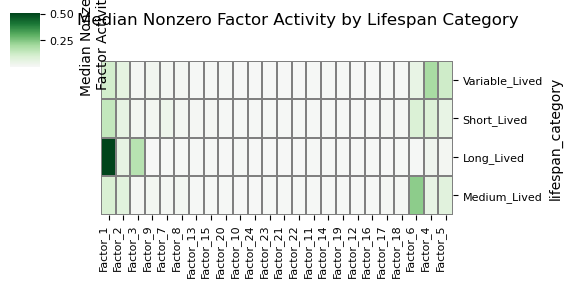

Saved: median_nonzero_factor_activity_by_lifespan_category.csv

Summary Statistics:
  Groups with data: 4
  Factors analyzed: 24
  Non-zero entries: 96
  Total entries: 96
  Sparsity: 0.0% zeros

Top active factor per group:
  Variable_Lived: Factor_4 (0.195)
  Short_Lived: Factor_1 (0.144)
  Long_Lived: Factor_1 (0.508)
  Medium_Lived: Factor_6 (0.234)

4. Analysis by Senescence Proneness:
Analyzing median nonzero factor activity by: senescence_proneness
Output suffix: senescence_proneness
Zero threshold: 0
Data shape: (80740, 25)
Groups in senescence_proneness: 4
Unique groups: ['High_Senescence_Prone', 'Low_Senescence_Prone', 'Moderate_Senescence_Prone', 'Variable_Senescence']
Median nonzero matrix shape: (4, 24)
Value range: 0.002 to 0.497
Using reference clustermap ordering...
Applied reference ordering: 4 rows, 24 cols
Saved: median_nonzero_factor_activity_by_senescence_proneness.pdf


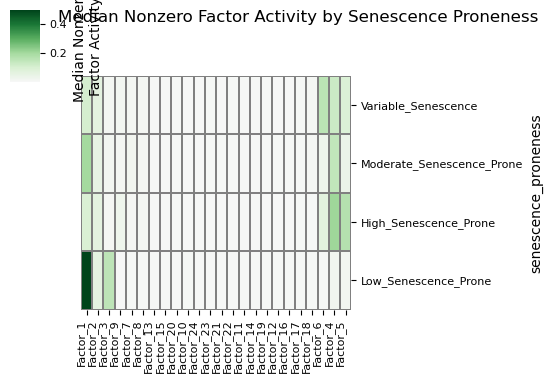

Saved: median_nonzero_factor_activity_by_senescence_proneness.csv

Summary Statistics:
  Groups with data: 4
  Factors analyzed: 24
  Non-zero entries: 96
  Total entries: 96
  Sparsity: 0.0% zeros

Top active factor per group:
  Variable_Senescence: Factor_6 (0.157)
  Moderate_Senescence_Prone: Factor_1 (0.199)
  High_Senescence_Prone: Factor_4 (0.207)
  Low_Senescence_Prone: Factor_1 (0.497)

5. Analysis by Functional Category:
Analyzing median nonzero factor activity by: functional_category
Output suffix: functional_category
Zero threshold: 0
Data shape: (80740, 25)
Groups in functional_category: 9
Unique groups: ['Barrier_Protection', 'Defense_Immunity', 'Exchange_Secretion', 'Information_Processing', 'Movement_Contraction', 'Other_Function', 'Regeneration_Development', 'Structure_Support', 'Transport_Circulation']
Median nonzero matrix shape: (9, 24)
Value range: 0.002 to 0.529
Using reference clustermap ordering...
Applied reference ordering: 9 rows, 24 cols
Saved: median_nonzero

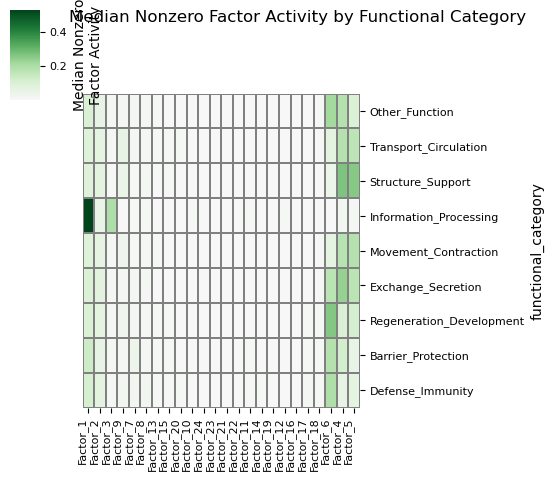

Saved: median_nonzero_factor_activity_by_functional_category.csv

Summary Statistics:
  Groups with data: 9
  Factors analyzed: 24
  Non-zero entries: 216
  Total entries: 216
  Sparsity: 0.0% zeros

Top active factor per group:
  Other_Function: Factor_6 (0.215)
  Transport_Circulation: Factor_4 (0.179)
  Structure_Support: Factor_4 (0.269)
  Information_Processing: Factor_1 (0.529)
  Movement_Contraction: Factor_5 (0.182)
  Exchange_Secretion: Factor_4 (0.236)
  Regeneration_Development: Factor_6 (0.261)
  Barrier_Protection: Factor_6 (0.179)
  Defense_Immunity: Factor_6 (0.192)


In [21]:
# Run analyses with different grouping variables
print("="*60)
print("RUNNING MEDIAN NONZERO FACTOR ACTIVITY ANALYSES")
print("="*60)

# 1. By simple category
print("\n1. Analysis by Simple Category:")
median_simple, g_median_simple = analyze_median_nonzero_activity_by_group(
    filtered_splice_adata, 
    groupby_column='simple_category',
    figsize=(6, 4)
)

# 2. By broad cell type (can use as reference for ordering)
print("\n2. Analysis by Broad Cell Type:")
median_broad, g_median_broad = analyze_median_nonzero_activity_by_group(
    filtered_splice_adata,
    groupby_column='broad_cell_type', 
    figsize=(8, 12)
)

# 3. By lifespan category (using broad cell type ordering as reference)
print("\n3. Analysis by Lifespan Category:")
median_lifespan, g_median_lifespan = analyze_median_nonzero_activity_by_group(
    filtered_splice_adata,
    groupby_column='lifespan_category',
    reference_clustermap=g_median_broad,  # Use broad cell type clustering
    figsize=(6, 3)
)

# 4. By senescence proneness
print("\n4. Analysis by Senescence Proneness:")
median_senescence, g_median_senescence = analyze_median_nonzero_activity_by_group(
    filtered_splice_adata,
    groupby_column='senescence_proneness',
    reference_clustermap=g_median_broad,  # Use broad cell type clustering
    figsize=(6, 4)
)

# 5. By functional category
print("\n5. Analysis by Functional Category:")
median_functional, g_median_functional = analyze_median_nonzero_activity_by_group(
    filtered_splice_adata,
    groupby_column='functional_category',
    reference_clustermap=g_median_broad,  # Use broad cell type clustering
    figsize=(6, 5)
)

In [22]:
# Extract X_PHI matrix and convert to DataFrame
phi = pd.DataFrame(
    filtered_splice_adata.obsm["X_PHI"],
    index=filtered_splice_adata.obs_names
)
phi.columns = [f"Factor_{i+1}" for i in range(phi.shape[1])]

phi_long = phi.reset_index().melt(id_vars="cell_id_clean", var_name="Factor", value_name="Activity")

In [23]:
phi_long["Factor"].unique()

array(['Factor_1', 'Factor_2', 'Factor_3', 'Factor_4', 'Factor_5',
       'Factor_6', 'Factor_7', 'Factor_8', 'Factor_9', 'Factor_10',
       'Factor_11', 'Factor_12', 'Factor_13', 'Factor_14', 'Factor_15',
       'Factor_16', 'Factor_17', 'Factor_18', 'Factor_19', 'Factor_20',
       'Factor_21', 'Factor_22', 'Factor_23', 'Factor_24'], dtype=object)

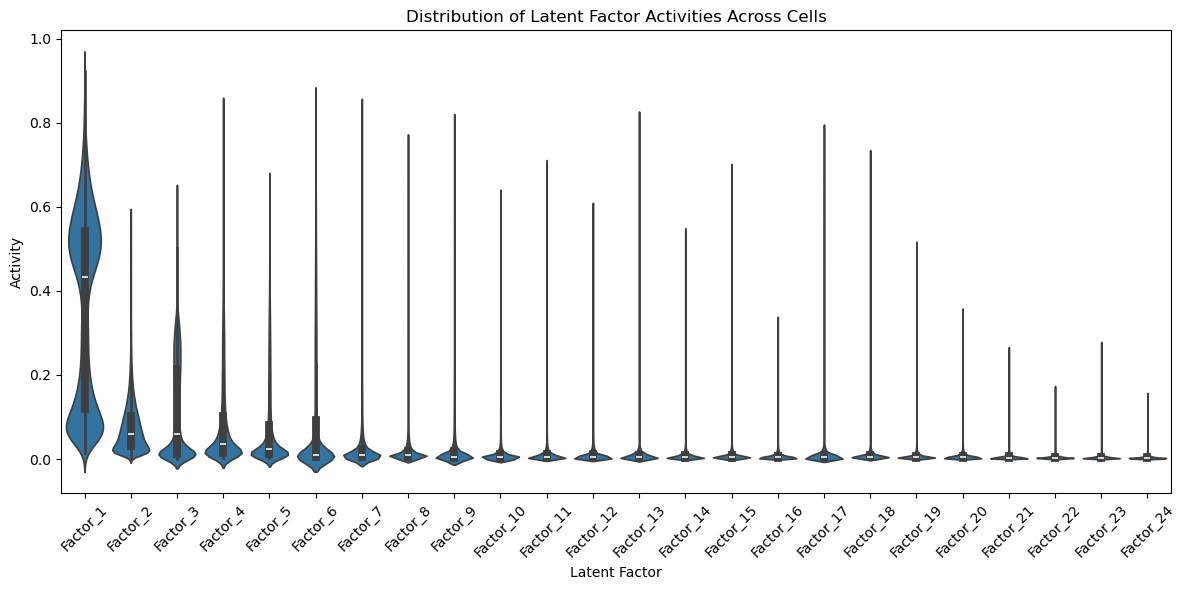

In [24]:
# Plot
plt.figure(figsize=(12, 6))  # Adjust width as needed
sns.violinplot(data=phi_long, x="Factor", y="Activity", inner="box", scale="width")
plt.xticks(rotation=45)
plt.title("Distribution of Latent Factor Activities Across Cells")
plt.xlabel("Latent Factor")
plt.ylabel("Activity")
plt.tight_layout()
plt.show()


In [25]:
filtered_splice_adata.obs["AgingScore_unweighted"] = filtered_ge_adata.obs["AgingScore_unweighted"]
filtered_splice_adata.obs["total_counts"] = filtered_ge_adata.obs["total_counts"]
filtered_splice_adata.obs["nuclear_class_log_norm"] = filtered_ge_adata.obs["nuclear_class_log_norm"]
filtered_splice_adata.obs["nuclear_score_log_norm"] = filtered_ge_adata.obs["nuclear_score_log_norm"]
filtered_splice_adata.obs["nuclear_rrna_log_norm"] = filtered_ge_adata.obs["nuclear_rrna_log_norm"]

# Add a senesnce marker score 

In [26]:
# Setup
phi_matrix = filtered_splice_adata.obsm["X_PHI"]
factor_names = [f"Factor_{i+1}" for i in range(phi_matrix.shape[1])]

# Build DataFrame
phi_df = pd.DataFrame(phi_matrix, index=filtered_splice_adata.obs_names, columns=factor_names)
phi_df["broad_cell_type"] = filtered_splice_adata.obs["broad_cell_type"].values
phi_df["age_group"] = filtered_splice_adata.obs["age_group"].values
phi_df["lifespan_category"] = filtered_splice_adata.obs["lifespan_category"].values

# Output dirs
output_dir_celltype = "./factor_violin_plots_by_celltype"
output_dir_agegroup = "./factor_violin_plots_by_agegroup"
output_dir_factors_by_celltype = "./factor_violin_per_celltype"

os.makedirs(output_dir_factors_by_celltype, exist_ok=True)
os.makedirs(output_dir_celltype, exist_ok=True)
os.makedirs(output_dir_agegroup, exist_ok=True)

In [27]:
# --- Plot by broad_cell_type ---
for factor in factor_names:
    # Order broad_cell_type by decreasing median activity
    medians = phi_df.groupby("broad_cell_type")[factor].median().sort_values(ascending=False)
    ordered_types = medians.index.tolist()

    plt.figure(figsize=(10, 5))
    sns.violinplot(
        data=phi_df, x="broad_cell_type", y=factor,
        order=ordered_types, inner="box", scale="width", 
        fill="simple_category"
    )
    plt.xticks(rotation=45, ha='right')
    plt.title(f"{factor} Activity Across Broad Cell Types")
    plt.xlabel("Broad Cell Type")
    plt.ylabel("Factor Activity")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir_celltype, f"{factor}_by_celltype_violin.pdf"))
    plt.close()

# --- Plot by age_group ---
for factor in factor_names:
    # Order age groups manually or by median if preferred
    age_order = phi_df["age_group"].unique().tolist()
    age_order.sort()  # assumes strings like "3m", "18m", ...

    plt.figure(figsize=(6, 5))
    sns.violinplot(
        data=phi_df, x="age_group", y=factor,
        order=age_order, inner="box", scale="width"
    )
    plt.title(f"{factor} Activity Across Age Groups")
    plt.xlabel("Age Group")
    plt.ylabel("Factor Activity")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir_agegroup, f"{factor}_by_agegroup_violin.pdf"))
    plt.close()

# Long-form DataFrame for plotting
phi_long = phi_df.reset_index().melt(
    id_vars=["cell_id_clean", "broad_cell_type", "age_group"],
    value_vars=factor_names,
    var_name="Factor", value_name="Activity"
)

# --- Plot one violin plot per cell type ---
for celltype in phi_df["broad_cell_type"].unique():
    subset = phi_long[phi_long["broad_cell_type"] == celltype]

    # Order factors by median activity in this cell type
    median_order = (
        subset.groupby("Factor")["Activity"]
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )

    plt.figure(figsize=(14, 5))
    sns.violinplot(
        data=subset, x="Factor", y="Activity",
        order=median_order, inner="box", scale="width"
    )
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Factor Activity in {celltype} (Ordered by Median)")
    plt.xlabel("Factor")
    plt.ylabel("Activity")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir_factors_by_celltype, f"{celltype}_factor_activity_violin.pdf"))
    plt.close()

In [28]:
# --- Plot by lifespan_category ---
for factor in factor_names:
    # Order age groups manually or by median if preferred
    age_order = phi_df["lifespan_category"].unique().tolist()
    age_order.sort()  # assumes strings like "3m", "18m", ...

    plt.figure(figsize=(6, 5))
    sns.violinplot(
        data=phi_df, x="lifespan_category", y=factor,
        order=age_order, inner="box", scale="width"
    )
    plt.title(f"{factor} Activity Across Age Groups")
    plt.xlabel("Life Span Group")
    plt.ylabel("Factor Activity")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir_agegroup, f"{factor}_by_cell_known_lifespan_violin.pdf"))
    plt.close()


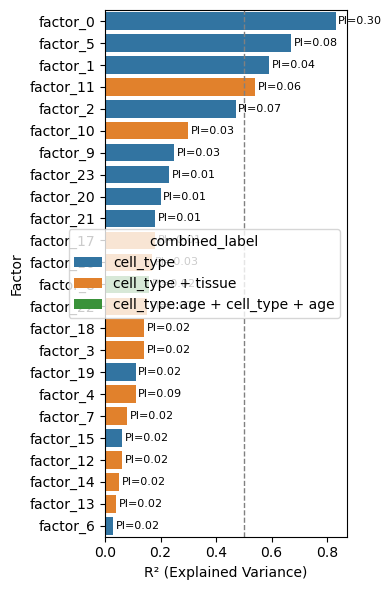

In [29]:
# read in factor labels 
factor_labels['combined_label'] = factor_labels.apply(relabel_covariate, axis=1)
fig, ax = plot_covariates_factor_labels(pi, factor_labels)

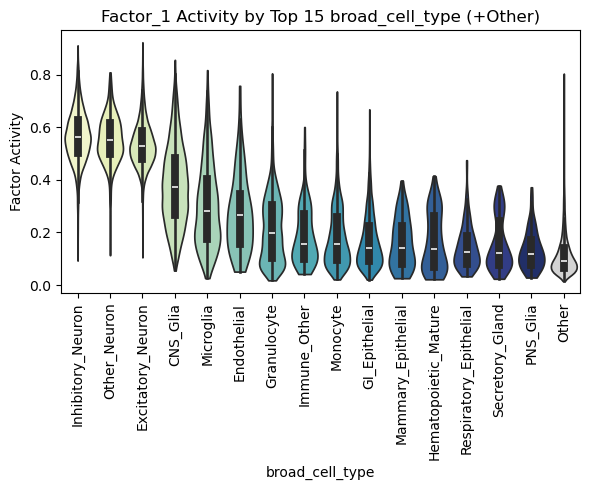

In [30]:
plot_factor_violin_sorted(
    adata=filtered_splice_adata,
    factor_list=["Factor_1"],
    groupby="broad_cell_type",
    top_n=15,
    cmap="YlGnBu",
    width=6,
    height=5
)


### Check clustering of "common" cell types between the two main datasets 

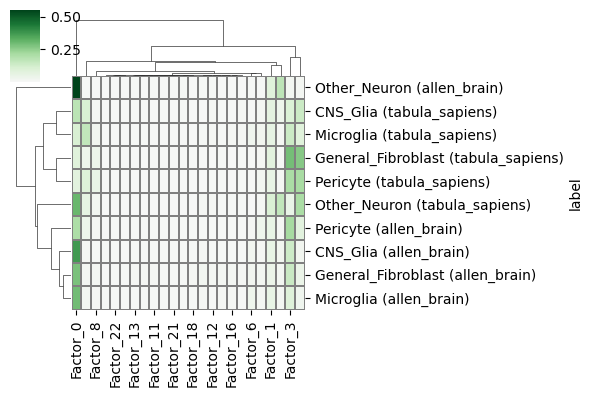

In [31]:
# Get cell type counts by dataset to get common cell types
# Get cell type counts by dataset to get common cell types
cell_type_counts = filtered_splice_adata.obs.groupby(['broad_cell_type', 'dataset']).size().unstack()
common_cell_types = cell_type_counts[(cell_type_counts["allen_brain"] > 0) & (cell_type_counts["tabula_sapiens"] > 0)]
common_cell_type_names = common_cell_types.index.tolist()
adata_common = filtered_splice_adata[filtered_splice_adata.obs["broad_cell_type"].isin(common_cell_type_names)].copy()
adata_common.obs["broad_cell_type"] = adata_common.obs["broad_cell_type"].cat.remove_unused_categories()

# Extract factor values
num_factors = adata_common.obsm["X_PHI"].shape[1]
factor_cols = [f"Factor_{i}" for i in range(num_factors)]
df = adata_common.obs[["broad_cell_type", "dataset"]].copy()
for i, col in enumerate(factor_cols):
    df[col] = adata_common.obsm["X_PHI"][:, i]

median_profiles = (
    df.groupby(["broad_cell_type", "dataset"])[factor_cols]
    .median()
    .reset_index()
)

# Create composite label
median_profiles["label"] = (
    median_profiles["broad_cell_type"].astype(str)
    + " (" +
    median_profiles["dataset"].astype(str)
    + ")"
)

median_profiles = median_profiles.set_index("label")[factor_cols]

# Cluster heatmap
g = sns.clustermap(
    median_profiles,
    method="average",
    metric="euclidean",
    cmap="PRGn",
    center=0,
    linewidths=0.2,
    linecolor='gray',
    figsize=(6, 4)
)

g.savefig("clustering_common_celltype_dataset_factors.pdf")
plt.show()

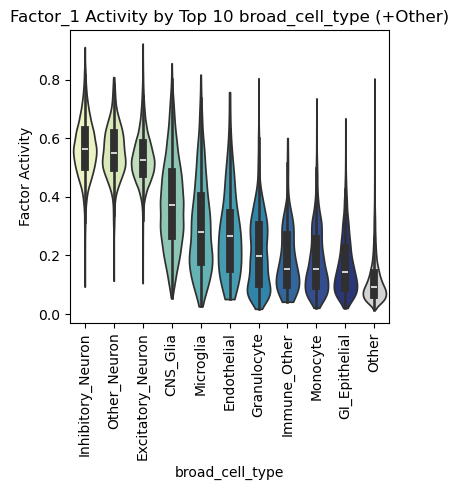

In [32]:
plot_factor_violin_sorted(
    adata=filtered_splice_adata,
    factor_list=["Factor_1"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)


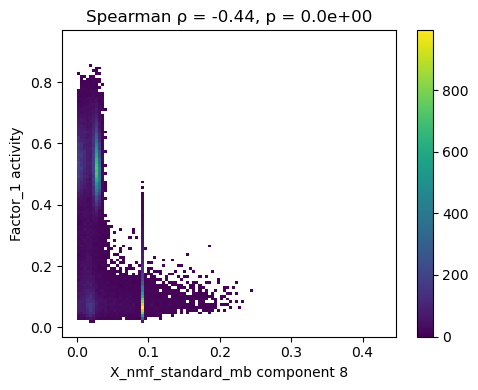

In [33]:
plot_factor_vs_embedding_component(
    filtered_splice_adata,
    filtered_ge_adata,
    factor_col="Factor_1",
    embedding="X_nmf_standard_mb",
    component_idx=8,
    plot_type="hist"
)


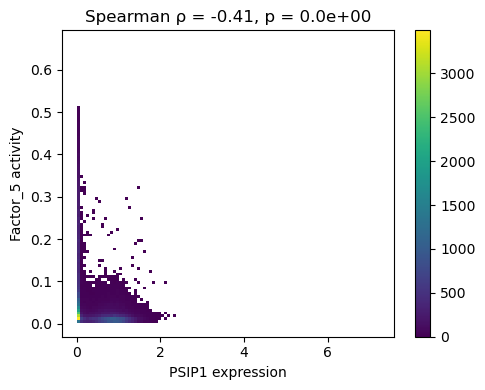

In [34]:
plot_gene_vs_factor_correlation(
    splice_adata=filtered_splice_adata,
    layer="log_norm",
    ge_adata=filtered_ge_adata,
    gene_name="PSIP1",
    factor_col="Factor_5",
    plot_type="hist"  # try "scatter", "kde", or "hist"
)


In [35]:
# Create imputed_PSI layer by multiplying X_PHI by psi_learned
# X_PHI shape: (C, K) where C = n_obs, K = n_factors
# psi_learned shape: (K, J) where K = n_factors, J = n_vars
# Result shape: (C, J) = (n_obs, n_vars)

X_PHI = splice_adata.obsm["X_PHI"]

# Get psi_learned from varm and transpose if needed
psi_learned = splice_adata.varm['psi_learned']
print(f"Original psi_learned shape: {psi_learned.shape}")

# Check if we need to transpose psi_learned
# It should be (K, J) to multiply with X_PHI (C, K)
if psi_learned.shape[0] != X_PHI.shape[1]:
    print("Transposing psi_learned to match dimensions")
    psi_learned = psi_learned.T

print(f"Final psi_learned shape: {psi_learned.shape}")
print(f"X_PHI shape: {X_PHI.shape}")

# Compute imputed PSI values
# Matrix multiplication: (C, K) × (K, J) = (C, J)
imputed_PSI = X_PHI @ psi_learned

print(f"Imputed PSI shape: {imputed_PSI.shape}")

# Add as a layer to the AnnData object
splice_adata.layers['imputed_PSI'] = imputed_PSI

print("Successfully added imputed_PSI layer to splice_adata.layers")

Original psi_learned shape: (25909, 24)
Transposing psi_learned to match dimensions
Final psi_learned shape: (24, 25909)
X_PHI shape: (80780, 24)
Imputed PSI shape: (80780, 25909)
Successfully added imputed_PSI layer to splice_adata.layers


In [36]:
# Direct UMAP on X_PHI
print("Computing neighbor graph on X_PHI...")
sc.pp.neighbors(filtered_splice_adata, 
                 n_neighbors=8,  # Can experiment with this
                 n_pcs=None,      # Use all dimensions (30)
                 use_rep='X_PHI',     # Use the current .X matrix (X_PHI)
                 random_state=42)
print("Neighbor graph computed")
# 
# Compute UMAP embedding
print("Computing UMAP embedding...")
sc.tl.umap(filtered_splice_adata, 
           min_dist=0.8,      # Controls how tightly packed points are
           spread=3.0,        # Controls how spread out the embedding is
           n_components=2,    # 2D embedding
           maxiter=500,       # Reduce iterations for speed
           random_state=42)

print("UMAP embedding computed")

Computing neighbor graph on X_PHI...
Neighbor graph computed
Computing UMAP embedding...
UMAP embedding computed


In [37]:
filtered_splice_adata

AnnData object with n_obs × n_vars = 80740 × 25909
    obs: 'cell_id', 'donor', 'sex', 'age', 'dataset', 'tissue', 'cell_type', 'broad_cell_type', 'cell_id_index', 'cell_id_clean', 'AgingScore_unweighted', 'AgingScore_pos', 'AgingScore_neg', 'nuclear_ratio_log_norm', 'seqtech', 'age_numeric', 'age_group', 'cell_type_module', 'functional_category', 'tissue_system', 'lifespan_category', 'simple_category', 'senescence_proneness', 'Factor_1', 'Factor_2', 'Factor_3', 'Factor_4', 'Factor_5', 'Factor_6', 'Factor_7', 'Factor_8', 'Factor_9', 'Factor_10', 'Factor_11', 'Factor_12', 'Factor_13', 'Factor_14', 'Factor_15', 'Factor_16', 'Factor_17', 'Factor_18', 'Factor_19', 'Factor_20', 'Factor_21', 'Factor_22', 'Factor_23', 'Factor_24', 'total_counts', 'nuclear_class_log_norm', 'nuclear_score_log_norm', 'nuclear_rrna_log_norm'
    var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'clean_gene

<Figure size 1000x800 with 0 Axes>

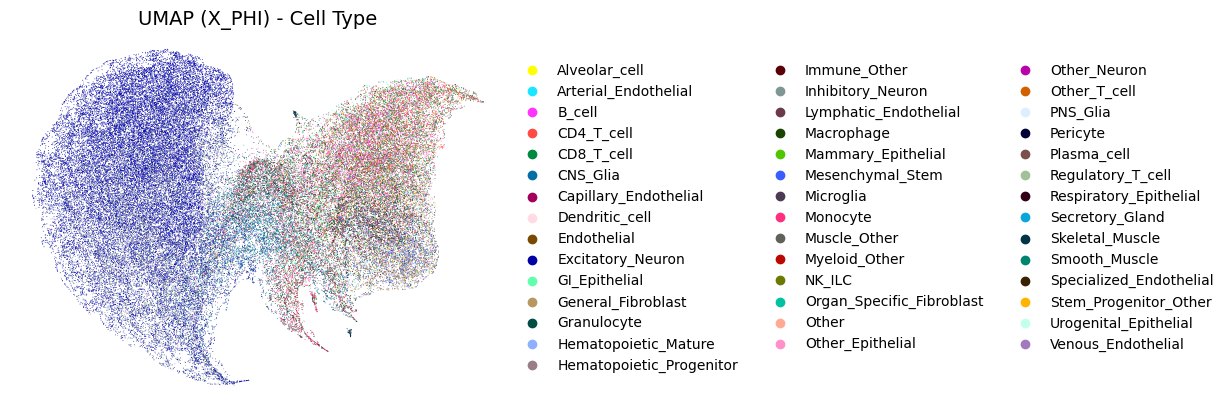

In [38]:
# Simple single plot by cell type
plt.figure(figsize=(10, 8))
sc.pl.embedding(filtered_splice_adata, basis="X_umap" , color='broad_cell_type',
                 show=False, frameon=False, 
                 legend_loc='right margin')  # Legend on the side, not on plot
plt.title('UMAP (X_PHI) - Cell Type', fontsize=14)
plt.show()

In [39]:
# plot_gene_and_factor_umap_from_phi(
#    splice_adata=splice_adata,
#    ge_adata=ge_adata,
#    layer="log_norm",
#    gene_name="PSIP1",
#    factor_name="Factor_6",
#    groupby=None,
#    group_level=None
#)

Analyzing 24 factors across 13 cell types
Processing Central_Nervous_System: 46522 cells vs 34218 others
Processing Cardiovascular_System: 3240 cells vs 77500 others
Processing Connective_Tissue: 4538 cells vs 76202 others
Processing Immune_System: 19673 cells vs 61067 others
Processing Digestive_System: 2160 cells vs 78580 others
Processing Smooth_Muscle_System: 571 cells vs 80169 others
Processing Musculoskeletal_System: 714 cells vs 80026 others
Processing Other_System: 2038 cells vs 78702 others
Processing Peripheral_Nervous_System: 67 cells vs 80673 others
Processing Lymphatic_System: 123 cells vs 80617 others
Processing Respiratory_System: 627 cells vs 80113 others
Processing Urogenital_System: 411 cells vs 80329 others
Processing Mammary_System: 56 cells vs 80684 others

Found 266 significant enrichments out of 312 tests


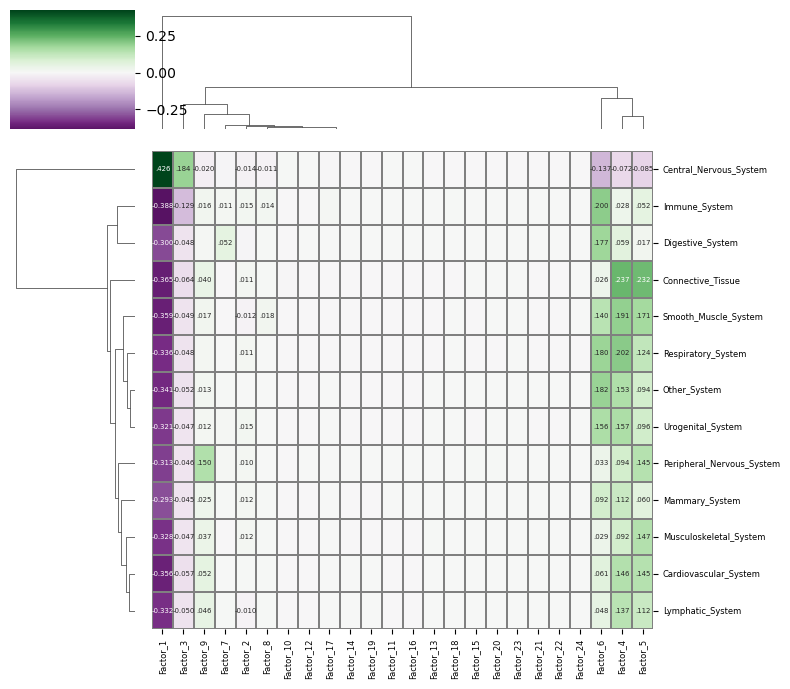

Effect size matrix shape: (13, 24)
Effect size range: -0.388 to 0.426


In [40]:
# Factor Enrichment Analysis - Effect Size Heatmap
from scipy.stats import mannwhitneyu
groupby = "tissue_system"

# Extract matrix
X_PHI = filtered_splice_adata.obsm["X_PHI"]
n_factors = X_PHI.shape[1]
factor_cols = [f"Factor_{i+1}" for i in range(n_factors)]

# Build DataFrame
df_all = pd.DataFrame(X_PHI, columns=factor_cols)
df_all[groupby] = filtered_splice_adata.obs[groupby].values

print(f"Analyzing {len(factor_cols)} factors across {df_all[groupby].nunique()} cell types")

# Parameters
min_median_threshold = 0.00  # Minimum median activity to consider
alpha = 0.05  # Significance threshold

# Store results
enrichment_results = []
effect_sizes = []

for cell_type in df_all[groupby].unique():
    cell_type_results = {}
    cell_type_effects = {}
    
    # Get cells for this cell type vs all others
    in_group_mask = df_all[groupby] == cell_type
    in_group_data = df_all[in_group_mask]
    out_group_data = df_all[~in_group_mask]
    
    print(f"Processing {cell_type}: {in_group_mask.sum()} cells vs {(~in_group_mask).sum()} others")
    
    for factor in factor_cols:
        # Get factor activity for in-group vs out-group
        in_group_activity = in_group_data[factor].values
        out_group_activity = out_group_data[factor].values
        
        # Calculate medians
        in_median = np.median(in_group_activity)
        out_median = np.median(out_group_activity)
        
        # Only proceed if in-group median meets threshold
        if in_median >= min_median_threshold:
            # Perform Mann-Whitney U test (Wilcoxon rank-sum)
            try:
                statistic, p_value = mannwhitneyu(
                    in_group_activity, 
                    out_group_activity, 
                    alternative='two-sided'
                )
                
                # Calculate effect size (difference in medians)
                effect_size = in_median - out_median
                
                # Calculate fold change (ratio of medians, handling zeros)
                if out_median > 0:
                    fold_change = in_median / out_median
                else:
                    fold_change = np.inf if in_median > 0 else 1.0
                
                # Store results
                enrichment_results.append({
                    'cell_type': cell_type,
                    'factor': factor,
                    'in_median': in_median,
                    'out_median': out_median,
                    'effect_size': effect_size,
                    'fold_change': fold_change,
                    'p_value': p_value,
                    'significant': p_value < alpha,
                    'n_in_group': len(in_group_activity),
                    'n_out_group': len(out_group_activity)
                })
                
                cell_type_effects[factor] = effect_size
                
            except Exception as e:
                print(f"Error processing {cell_type} - {factor}: {e}")
                cell_type_effects[factor] = 0
        else:
            # Below threshold - set to 0
            cell_type_effects[factor] = 0
    
    effect_sizes.append(cell_type_effects)

# Convert to DataFrame for easy manipulation
enrichment_df = pd.DataFrame(enrichment_results)
print(f"\nFound {enrichment_df['significant'].sum()} significant enrichments out of {len(enrichment_df)} tests")

# Create effect size matrix for heatmap
effect_size_matrix = pd.DataFrame(effect_sizes)
effect_size_matrix.index = df_all[groupby].unique()

# Fill any missing values with 0
effect_size_matrix = effect_size_matrix.fillna(0)

# Assuming effect_size_matrix is a pandas DataFrame
def format_val(val):
    if abs(val) < 0.01:
        return ""  # leave blank for very small values
    elif abs(val) < 1:
        return f"{val:.3f}".lstrip("0")  # e.g., 0.321 → .321
    else:
        return f"{val:.2f}"  # leave integers and large vals with 2 decimals

formatted_annot = effect_size_matrix.copy().applymap(format_val)

g6 = sns.clustermap(
    effect_size_matrix,
    cmap="PRGn",  # Red = enriched, Blue = depleted
    center=0,
    figsize=(8, 7),
    xticklabels=True,
    yticklabels=True,
    row_cluster=True,
    col_cluster=True,
    linewidths=0.2,
    linecolor='gray',
    annot=formatted_annot,
    fmt="",  # Necessary for custom string annotations
    annot_kws={"size": 5}  # Small font for annotations
)

# Set font size of tick labels
g6.ax_heatmap.set_xticklabels(g6.ax_heatmap.get_xticklabels(), fontsize=6, rotation=90)
g6.ax_heatmap.set_yticklabels(g6.ax_heatmap.get_yticklabels(), fontsize=6)

plt.tight_layout()
plt.savefig(f"factor_enrichment_effect_size_by_{groupby}.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.show()

print(f"Effect size matrix shape: {effect_size_matrix.shape}")
print(f"Effect size range: {effect_size_matrix.values.min():.3f} to {effect_size_matrix.values.max():.3f}")

### Look at sig junctions from differential splicing analysis

In [41]:
# Run the analysis
print("="*60)
print("TOP JUNCTIONS PER FACTOR PSI ANALYSIS")
print("="*60)

# Step 1: Get top junctions per factor
top_junctions_dict, subset_splice_adata, junction_factor_map = get_top_junctions_per_factor(
    diff_spl, 
    filtered_splice_adata, 
    top_n=10, 
    effect_size_col='abs_effect_size'
)

print(f"\nJunction-Factor mapping summary:")
print(junction_factor_map.head(10))

TOP JUNCTIONS PER FACTOR PSI ANALYSIS
Getting top 10 junctions per factor...
Ranking by: abs_effect_size
Found 24 factors: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Factor 0: 10 junctions, effect size range: 0.912 - 0.964
Factor 1: 10 junctions, effect size range: 0.956 - 0.994
Factor 2: 10 junctions, effect size range: 0.914 - 0.994
Factor 3: 10 junctions, effect size range: 0.935 - 0.954
Factor 4: 10 junctions, effect size range: 0.907 - 0.997
Factor 5: 10 junctions, effect size range: 0.982 - 0.995
Factor 6: 10 junctions, effect size range: 0.838 - 0.931
Factor 7: 10 junctions, effect size range: 0.621 - 0.800
Factor 8: 10 junctions, effect size range: 0.857 - 0.981
Factor 9: 10 junctions, effect size range: 0.928 - 0.966
Factor 10: 10 junctions, effect size range: 0.931 - 0.979
Factor 11: 10 junctions, effect size range: 0.910 - 0.963
Factor 12: 10 junctions, effect size range: 0.720 - 0.830
Factor 13: 10 junctions, effect size range: 0.

In [42]:
# Get unique junction indices
unique_junctions = junction_factor_map['junction_idx'].unique()

# Extract PSI learned values for these junctions
psi_subset = filtered_splice_adata.varm['psi_learned'][unique_junctions, :]

psi_subset.shape

(222, 24)

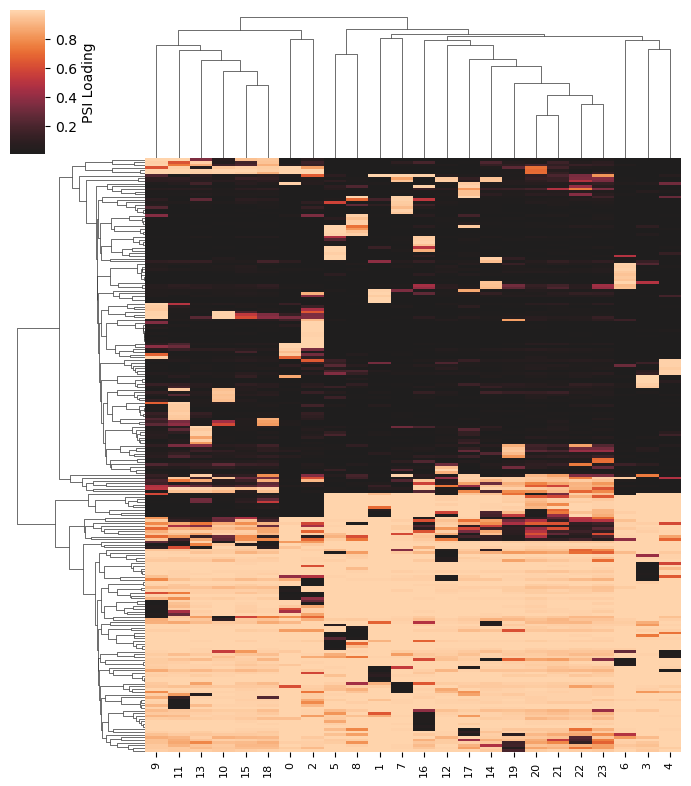

In [43]:
# Create clustermap
g = sns.clustermap(psi_subset, center=0, figsize=(7, 8),
                  xticklabels=True, yticklabels=False,
                  cbar_kws={'label': 'PSI Loading'})

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=6)
plt.show()

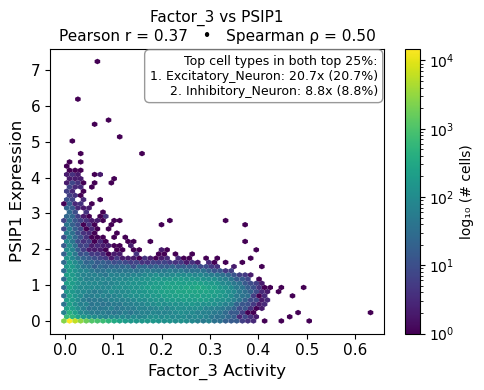


CELL TYPE ENRICHMENT ANALYSIS

Top 10% thresholds:
  Factor_3: >= 0.215
  PSIP1: >= 0.890

CELL TYPES ENRICHED IN TOP 10% Factor_3 ACTIVITY:
--------------------------------------------------
 1. Excitatory_Neuron           5.6x (55.8% = 17,103/30,669)
 2. Other_Neuron                2.7x (27.4% = 87/318)
 3. Inhibitory_Neuron           2.7x (26.6% = 2,891/10,861)
 4. Hematopoietic_Mature        0.3x ( 3.1% = 4/128)
 5. Respiratory_Epithelial      0.1x ( 1.1% = 2/188)
 6. Smooth_Muscle               0.1x ( 0.9% = 5/571)
 7. Immune_Other                0.1x ( 0.8% = 1/131)
 8. CNS_Glia                    0.1x ( 0.7% = 28/3,872)
 9. Arterial_Endothelial        0.1x ( 0.6% = 1/156)
10. Secretory_Gland             0.1x ( 0.6% = 1/167)

CELL TYPES ENRICHED IN TOP 10% PSIP1 EXPRESSION:
--------------------------------------------------
 1. Excitatory_Neuron           3.9x (39.5% = 12,112/30,669)
 2. Inhibitory_Neuron           3.6x (36.2% = 3,937/10,861)
 3. Other_Neuron                3.1x

(0.36603851774962276, 0.4952692552500564)

In [44]:
# Single hex-bin plot
plot_factor_rbp_hexbin(filtered_splice_adata, filtered_ge_adata, "Factor_3", "PSIP1", percentile=75)